Start by generating the data

(0.0, 20.0)

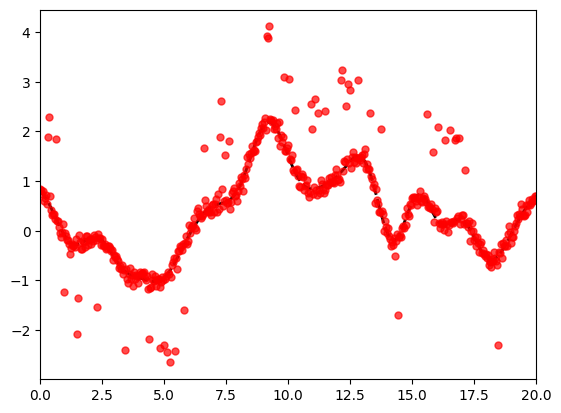

In [1]:
from typing import Optional, Any

import tensorflow as tf
import numpy as np
from check_shapes import check_shapes, inherit_check_shapes
from typing import Optional, Tuple, Type, Union, cast
import tensorflow_probability as tfp
import gpflow

from gpflow.base import InputData, MeanAndVariance, RegressionData, TensorData
from gpflow.kernels import Kernel
from gpflow.likelihoods import Gaussian
from gpflow.mean_functions import MeanFunction
from gpflow.models.model import GPModel
from gpflow.models.training_mixins import InternalDataTrainingLossMixin
from gpflow.models.util import data_input_to_tensor
from gpflow.config import default_float, default_jitter
from gpflow.utilities import to_default_float
from gpflow import posteriors
from gpflow.utilities.ops import eye
import random

from numpy.lib.twodim_base import histogram2d
from tensorboard.plugins.histogram.summary import histogram
from tensorflow.python.ops.variables import trainable_variables

import w 

import tensorflow as tf
import numpy as np
import gpflow

import matplotlib.pyplot as plt
tf.keras.config.set_floatx('float64')
seed = 10

#set seed
np.random.seed(seed)
tf.random.set_seed(seed)

#create X
n_points = 500
sigma_n = 0.1
#percentage of points in x which are biased
percent_miss=0.1


#
lengthscale = 1
variance = 1

variance_out = 2

kernel=gpflow.kernels.SquaredExponential(lengthscales=lengthscale, variance=variance)

x = np.linspace(0, 20, n_points).reshape(n_points, 1)
f = np.random.multivariate_normal(mean=np.zeros(len(x)) ,cov=kernel(x, x)).reshape(n_points, 1)

i_obs = np.random.choice(
    np.arange(0, n_points, 1), int( n_points), replace=False)

y_obs = f[i_obs] + np.random.normal(scale=sigma_n, size=n_points).reshape(n_points, 1)
x_obs = x[i_obs]

arr1inds = x_obs[:,0].argsort()
x_obs = x_obs[arr1inds]
y_obs = y_obs[arr1inds]

i_mis = np.random.choice(
    np.arange(0, n_points, 1), int(percent_miss * n_points), replace=False)

upp=2
low=1
y_mis_pos = y_obs[i_mis[(y_obs[i_mis]>0)[:,0]]]  + np.random.uniform(low, upp, size=len(i_mis[(y_obs[i_mis]>0)[:,0]])).reshape(len(i_mis[(y_obs[i_mis]>0)[:,0]]),1)
y_mis_neg = y_obs[i_mis[(y_obs[i_mis]<=0)[:,0]]]  - np.random.uniform(low, upp, size=len(i_mis[(y_obs[i_mis]<=0)[:,0]])).reshape(len(i_mis[(y_obs[i_mis]<=0)[:,0]]),1)
y_obs[i_mis[(y_obs[i_mis]>0)[:,0]]] = y_mis_pos
y_obs[i_mis[(y_obs[i_mis]<=0)[:,0]]] = y_mis_neg
X=x
y=y_obs

plt.plot(x, f, color='black', ls='--', lw=2)
plt.plot(x_obs, y_obs, 'r.', ms=10, alpha=0.7)
plt.xlim(x[0], x[-1])

Altamirano loss

In [62]:
from sklearn.model_selection import train_test_split
import time
import gpflow
import tensorflow as tf
import tensorflow_probability as tfp
import matplotlib.pyplot as plt
import numpy as np
import w 


class GVI_RCGP_alpha(gpflow.models.BayesianModel):
    def __init__(self, X, y, Kernel, objective="GVI", Sigma_f_structure="c_f",weightfunction=w.IMQ,C=1,
                 lambda_method="constant", inducing=[.0], alpha=0.5,
                 sigma=.25,test_size=0.15):
        super().__init__()
        self.X = X
        self.y = y

        # define if we are gonna optimize through the GVI or predictive.
        self.objective = objective
        self.alpha = gpflow.Parameter(alpha, trainable=False)
        if objective == "GVI":
            self.sigma = gpflow.Parameter(sigma, trainable=False)
        else:
            self.sigma = gpflow.Parameter(1., transform=gpflow.utilities.positive(), trainable=True)
        # define the weight
        self.weightfunction = weightfunction(C=C)
        
        self.test_size=test_size
        # GP parameters
        self.kernel = Kernel
        self.inducing_variable = inducing

        # set structure for \Sigma_f
        if Sigma_f_structure == "c_f":
            self.c_f = gpflow.Parameter(1., transform=gpflow.utilities.positive(), trainable=True)
        else:
            self.Kernel_inducing = gpflow.kernels.SquaredExponential(lengthscales=0.1, variance=0.1)
        self.Sigma_f_structure = Sigma_f_structure

        # set lambda
        if lambda_method == "constant":
            self.lambda_i = tf.constant(1., dtype=tf.float64)
        elif lambda_method == "predictive" and objective == "predictive":
            self.lambda_i = gpflow.Parameter(1., transform=gpflow.utilities.positive(), trainable=True,
                                             dtype=tf.float64)
        else:
            print("lambda method unknown")
        self.lambda_method = lambda_method

    tf.keras.backend.set_floatx('float64')

    # needed for the class
    def maximum_log_likelihood_objective(self):
        pass

    # update Sigma_f according to method.
    @tf.function
    def compute_sigma_f(self, X,J_w):
        if self.Sigma_f_structure == "c_f":
            K = self.kernel(X, X)
            Sigma_f = self.c_f * K @ tf.linalg.inv(
                    K + self.sigma ** 2 / self.lambda_i * J_w) @J_w * self.sigma ** 2 / self.lambda_i
        else:
            K = self.kernel(X, X)
            K_uu = self.Kernel_inducing(self.inducing_variable, self.inducing_variable)
            K_uf = self.Kernel_inducing(self.inducing_variable, X)
            K_fu = tf.transpose(K_uf)
            K_uu_inv = tf.linalg.inv(K_uu + tf.linalg.eye(K_uu.shape[0], dtype=tf.float64) * gpflow.default_jitter())
            Sigma_f = K_fu @ K_uu_inv @ K_uf
        return K, Sigma_f

    @tf.function
    def train_step(self):
        if self.objective == "GVI":
            loss = self.GVI_step()
        else:
            loss = self.Pred_step()
        return loss
    
    def compute_weights(self,X,y):
        W_y=self.weightfunction.W(X,y)
        m_y=self.weightfunction.dy(X,y)**2
        J_w = tf.linalg.tensor_diag(tf.squeeze(tf.math.pow(W_y, -2)))*self.sigma**2
        J_w_inv = tf.linalg.tensor_diag(tf.squeeze(tf.math.pow(W_y, 2)))/self.sigma**2
        return m_y,J_w,J_w_inv


    def pred_log_prob(self, y, mu_f, sigma_y):
        # ensure 1-D vectors and float64 (gpflow/TensorFlow prefer float64 in many setups)
        y = tf.reshape(tf.cast(y, tf.float64), [-1])
        mu_f = tf.reshape(tf.cast(mu_f, tf.float64), [-1])
        sigma_y = tf.cast(sigma_y, tf.float64)

        # If sigma_y is a full covariance matrix, take diagonal (marginal variances)
        if sigma_y.shape.ndims == 2 and sigma_y.shape[0] == sigma_y.shape[1]:
            var = tf.linalg.diag_part(sigma_y)
        else:
            var = tf.reshape(sigma_y, [-1])


        # quadratic term (scalar)
        term_quad = 0.5 * tf.reduce_sum((y - mu_f) ** 2 / var)

        # log-determinant / normalizer term (scalar)
        term_log = 0.5 * tf.reduce_sum(tf.math.log(var))

        # optional extra term you had: make sure to treat self.sigma numerically
        try:
            inv_sigma2 = tf.math.reciprocal(tf.square(tf.cast(self.sigma, tf.float64)))
        except Exception:
            inv_sigma2 = tf.constant(0.0, dtype=tf.float64)

        term3 = 0.5 * inv_sigma2 * tf.reduce_sum(var + tf.square(tf.cast(self.sigma, tf.float64)))

        return term_quad + term_log + term3

    def GVI_step(self):
        #update weights
        m_y,J_w,J_w_inv=self.compute_weights(self.X,self.y)
        K, Sigma_f = self.compute_sigma_f(self.X,J_w)

        N = tf.cast(tf.shape(K)[0], tf.float64)
        eye = tf.eye(N, dtype=K.dtype)
        jitter = eye * 1e-6
        

        
        #compute matrixes
        Sigma_a = self.alpha * K + (1.0 - self.alpha) * Sigma_f
        Sigma_a_inv = tf.linalg.inv(Sigma_a + jitter)
        
        #update mu
        q1 = self.alpha*Sigma_a@tf.linalg.inv(self.alpha * Sigma_a + J_w*self.lambda_i)
        mu_f = tf.matmul(q1, (self.y-m_y))

        # Log-determinants
        ld_Sig_a = tf.linalg.logdet(Sigma_a + jitter)
        ld_Sig_f = tf.linalg.logdet(Sigma_f + jitter)
        ld_K = tf.linalg.logdet(K + jitter)


        term1 = (tf.transpose(mu_f)@J_w_inv@mu_f
               +tf.linalg.trace(Sigma_f@J_w_inv)
               -2*tf.transpose(mu_f)@J_w_inv@(self.y-m_y))
        term2 = 0.5 * self.alpha * tf.transpose(mu_f) @ (Sigma_a_inv) @ (mu_f)
        term3 = -1.0 / (2.0 * (self.alpha - 1.0)) * (ld_Sig_a + (self.alpha - 1.0) * ld_Sig_f - self.alpha * ld_K)
        loss = tf.squeeze(term1 + term2 + term3)
        
        self.sigma.assign(tf.squeeze(tf.sqrt(tf.transpose(self.y-mu_f-m_y)@J_w_inv@(self.y-mu_f-m_y)/tf.reduce_sum(J_w_inv))))
        return loss

    def Pred_step(self):
        X_train, X_test, y_train, y_test = train_test_split(self.X, self.y, test_size=self.test_size, random_state=0)
        
        
        #define weights and select with the same indexes
        m_y_train,J_w_train,J_w_inv_train=self.compute_weights(X_train,y_train)

        K, Sigma_f = self.compute_sigma_f(X_train,J_w_train)

        N = tf.cast(tf.shape(K)[0], tf.float64)

        eye = tf.eye(N, dtype=K.dtype)
        jitter = eye * 1e-6
        K_inv = tf.linalg.inv(K + jitter)

        Sigma_a = self.alpha * K + (1.0 - self.alpha) * Sigma_f

        q1 = self.alpha*Sigma_a@tf.linalg.inv(self.alpha * Sigma_a + J_w_train*self.lambda_i)
        mu_f = tf.matmul(q1, (y_train-m_y_train))

        K_star = self.kernel(X_test, X_train)
        K_star_star = self.kernel(X_test, X_test)

        mu_p = K_star @ K_inv @ mu_f
        A = K_star_star - K_star @ K_inv @ tf.transpose(K_star) \
            + K_star @ K_inv @ Sigma_f @ tf.transpose(K_star @ K_inv)

        # use diagonal of covariance directly
        sigma_p = tf.linalg.diag_part(A)  # no inverse here

        
        var_y = sigma_p + tf.cast(self.sigma ** 2, tf.float64)
        term1 = self.pred_log_prob(y_test, mu_p, var_y)

        return term1


    def sample_y(self, n_samples=100):
        N = self.X.shape[0]
        f = np.random.multivariate_normal(mean=tf.squeeze(self.mu_f), cov=self.Sigma_f, size=n_samples)  # put the
        noise = tf.random.normal(
                shape=(n_samples, N),
                mean=0.0,
                stddev=self.sigma,  # can be Parameter/Variable
                dtype=tf.float64
            )
        return f + noise

    def predict_ins(self):
        m_y,J_w,J_w_inv=self.compute_weights(self.X,self.y)
        K, Sigma_f = self.compute_sigma_f(self.X,J_w)

        Sigma_a = self.alpha * K + (1.0 - self.alpha) * Sigma_f
        q1 = self.alpha*Sigma_a@tf.linalg.inv(self.alpha * Sigma_a + J_w*self.lambda_i)
        mu_f = tf.matmul(q1, (self.y-m_y))
        self.mu_f = mu_f
        self.Sigma_f = Sigma_f
        self.K = K

    def stable_solve(self, mat, rhs):
        jitter = tf.eye(tf.shape(mat)[0], dtype=mat.dtype) * 1e-6
        L = tf.linalg.cholesky(mat + jitter)
        return tf.linalg.cholesky_solve(L, rhs)

    def internal_opt(self, n_it=10):
        optimizer = tf.optimizers.Adam(learning_rate=0.01)
        
        for i in range(n_it):
            with tf.GradientTape(persistent=True) as tape:
                loss = self.train_step()
            grads = tape.gradient(loss, self.trainable_variables)
            optimizer.apply_gradients(zip(grads, self.trainable_variables))
        opt = gpflow.optimizers.Scipy()
        opt.minimize(self.train_step, self.trainable_variables)

    def predict_out(self, X):
        K_xold_xold = self.kernel(self.X, self.X)
        K_xold_xnew = self.kernel(X, self.X)
        jitter = 1e-6 * tf.eye(tf.shape(K_xold_xold)[0], dtype=K_xold_xold.dtype)
        K_inv = tf.linalg.inv(K_xold_xold + jitter)

        #compute variance
        f_var = self.kernel(X,X) - K_xold_xnew @ K_inv @ tf.transpose(K_xold_xnew)+ K_xold_xnew @ K_inv @ self.Sigma_f @ K_inv @ tf.transpose(K_xold_xnew)
        return K_xold_xnew @ K_inv @ self.mu_f, tf.linalg.diag_part(f_var)

    def compute_lambda_stat(self, n_samples=100):
        # sample_y returns (n_samples, N)
        y_sampl = self.sample_y(n_samples)  # (n_samples, N)
        mu = tf.reshape(self.mu_f, [-1])  # (N,)
        variance = tf.linalg.diag_part(self.Sigma_f)
        variance += self.sigma ** 2
        # per-sample mean squared error (one scalar per sampled function)
        s = tf.reduce_mean((y_sampl - tf.reshape(mu, [1, -1])) ** 2 / variance, axis=1)  # (n_samples,)
        # scalar mean squared residual on training data
        y_vec = tf.reshape(self.y, [-1])  # (N,)
        s_mean = tf.reduce_mean((y_vec - mu) ** 2 / variance)  # scalar

        return tf.reduce_mean(tf.cast(s < s_mean, tf.float32))

    def pp_alg(self,lambda_values = [1., 0.1, 0.5, 0.7, 0.8, 0.9, 1.1, 1.2, 1.5, 2., 10.]):
        test_values = []
        for lambda_i in lambda_values:
            self.lambda_i = lambda_i
            self.internal_opt()
            self.predict_ins()
            test_values.append(self.compute_lambda_stat())

        ##choose lambda with best
        self.lambda_i = lambda_values[test_values.index(min(test_values))]
        ##fit model with that lambda
        opt = gpflow.optimizers.Scipy()
        opt.minimize(self.train_step, self.trainable_variables)


Test the RCGP alpha

In [16]:
N=X.shape[0]
Z =X[np.random.choice(N, 20, replace=False), :]
kernel = gpflow.kernels.SquaredExponential(lengthscales=1.0, variance=1.0)
inducing_variable = gpflow.Parameter(Z,trainable=False)
model = GVI_RCGP_alpha(X,y,kernel)
model.internal_opt()
model.predict_ins()
tf.reduce_mean((model.mu_f - f) ** 2)

<tf.Tensor: shape=(), dtype=float64, numpy=0.010156008550282617>

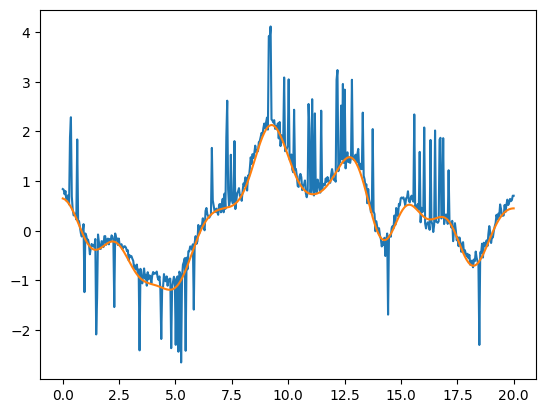

In [17]:
plt.plot(X,y)
plt.plot(X,model.mu_f)

SRCGP ALPHA


In [38]:
import tensorflow as tf
import tensorflow_probability as tfp
import gpflow

tfpk = tfp.math.psd_kernels

class GVI_SRCGPR_alpha(gpflow.models.BayesianModel):
    def __init__(self, X, y, inducing, sigma=1., structure="Diag", alpha=0.5,
                 test_size=0.1, weightfunction=None, C=1., objective="GVI"):
        super().__init__()
        self.X = tf.cast(X, tf.float64)
        self.y = tf.cast(y, tf.float64)
        self.inducing_variable = tf.cast(inducing, tf.float64)
        self.N_u = inducing.shape[0]
        self.objective = objective

        # Variational parameters
        self.alpha = gpflow.Parameter(alpha, trainable=False, dtype=tf.float64)
        if structure == "Diag":
            self.Var_q = gpflow.Parameter([1.] * self.N_u, transform=gpflow.utilities.positive())
        else:
            self.Var_q = gpflow.Parameter(tf.linalg.eye(self.N_u), transform=gpflow.utilities.triangular())
        self.structure = structure
        self.test_size = test_size

        # Kernel replaced with TFP ExponentiatedQuadratic
        self.kernel = tfpk.ExponentiatedQuadratic(
    amplitude=tf.constant(1.0, dtype=tf.float64),
    length_scale=tf.constant(1.0, dtype=tf.float64),
)


        # Other GP parameters
        self.lambda_i = 1.
        self.sigma = tf.Variable(sigma, dtype=tf.float64, trainable=False)
        self.weightfunction = weightfunction(C=C) if weightfunction is not None else None

    def stable_solve(self, mat, rhs):
        jitter = tf.eye(tf.shape(mat)[0], dtype=mat.dtype) * 1e-6
        L = tf.linalg.cholesky(mat + jitter)
        return tf.linalg.cholesky_solve(L, rhs)

    def compute_weights(self, X, y):
        if self.weightfunction is None:
            N = X.shape[0]
            return tf.zeros([N, 1], dtype=tf.float64), tf.eye(N, dtype=tf.float64), tf.eye(N, dtype=tf.float64)
        W_y = self.weightfunction.W(X, y)
        m_y = self.weightfunction.dy(X, y)**2
        J_w = tf.linalg.tensor_diag(tf.squeeze(tf.math.pow(W_y, -2))) * self.sigma**2
        J_w_inv = tf.linalg.tensor_diag(tf.squeeze(tf.math.pow(W_y, 2))) / self.sigma**2
        return m_y, J_w, J_w_inv

    @tf.function
    def train_step(self):
        if self.objective == "GVI":
            return self.GVI_step()
        else:
            return self.Pred_step()

    def GVI_step(self):
        K_uu = self.kernel.matrix(self.inducing_variable, self.inducing_variable)
        K_uf = self.kernel.matrix(self.inducing_variable, self.X)
        K_fu = tf.transpose(K_uf)

        N = tf.cast(tf.shape(self.X)[0], tf.float64)
        jitter = tf.eye(self.N_u, dtype=tf.float64) * 1e-6
        K_uu_inv = tf.linalg.inv(K_uu + jitter)

        if self.structure == "Diag":
            Sigma_u = tf.linalg.diag(self.Var_q)
        else:
            Sigma_u = self.Var_q @ tf.transpose(self.Var_q)

        Sigma_a = self.alpha * K_uu + (1.0 - self.alpha) * Sigma_u
        Sigma_a_inv = tf.linalg.inv(Sigma_a + jitter)

        m_y, J_w, J_w_inv = self.compute_weights(self.X, self.y)

        precision_mid = self.alpha * Sigma_a_inv + (
                        K_uu_inv @ K_uf @ J_w @ K_fu @ K_uu_inv) / self.sigma ** 2 * self.lambda_i
        q1 = tf.linalg.inv(precision_mid + jitter)
        q2 = tf.matmul(K_uu_inv @ K_uf, J_w @ self.y) / (self.sigma ** 2) * self.lambda_i
        mu_u = tf.matmul(q1, q2)

        residual = self.y - K_fu @ K_uu_inv @ mu_u
        T1 = K_uu_inv @ (K_uf @ J_w @ K_fu)
        T2 = T1 @ (K_uu_inv @ Sigma_u)
        
        #kernel diagonal, to specify if we change the kernel

        term1 = 0.5 * tf.reduce_sum(tf.square(residual)) * (self.sigma ** -2) * self.lambda_i
        term1 += 0.5 * self.lambda_i * (N * tf.squeeze(self.kernel.amplitude) - tf.linalg.trace(T1) + tf.linalg.trace(T2)) * self.lambda_i
        term1 += N * tf.math.log(self.sigma)

        term2 = 0.5 * self.alpha * tf.reduce_sum(mu_u * (Sigma_a_inv @ mu_u))

        ld_K = tf.linalg.logdet(K_uu + jitter)
        ld_Sig_a = tf.linalg.logdet(Sigma_a + jitter)
        ld_Sig_u = tf.linalg.logdet(Sigma_u + jitter)
        term3 = -1.0 / (2.0 * (self.alpha - 1.0)) * (ld_Sig_a + (self.alpha - 1.0) * ld_Sig_u - self.alpha * ld_K)

        self.sigma.assign(tf.squeeze(tf.sqrt(tf.transpose(self.y - K_fu @ K_uu_inv @ mu_u - m_y) @ J_w_inv @ (self.y - K_fu @ K_uu_inv @ mu_u - m_y) / tf.reduce_sum(J_w_inv))))

        return tf.squeeze(term1 + term2 + term3)

    def predict_ins(self):
        K_uu = self.kernel.matrix(self.inducing_variable, self.inducing_variable)
        K_uf = self.kernel.matrix(self.inducing_variable, self.X)
        K_fu = tf.transpose(K_uf)

        jitter = tf.eye(self.N_u, dtype=tf.float64) * 1e-6
        K_uu_inv = tf.linalg.inv(K_uu + jitter)

        if self.structure == "Diag":
            Sigma_u = tf.linalg.diag(self.Var_q)
        else:
            Sigma_u = self.Var_q @ tf.transpose(self.Var_q)
        Sigma_a = self.alpha * K_uu + (1.0 - self.alpha) * Sigma_u
        Sigma_a_inv = tf.linalg.inv(Sigma_a + jitter)

        m_y, J_w, _ = self.compute_weights(self.X, self.y)

        precision_mid = self.alpha * Sigma_a_inv + (
                        K_uu_inv @ K_uf @ J_w @ K_fu @ K_uu_inv) / self.sigma ** 2 * self.lambda_i
        q1 = tf.linalg.inv(precision_mid + jitter)
        q2 = tf.matmul(K_uu_inv @ K_uf, J_w @ (self.y - m_y)) / (self.sigma ** 2) * self.lambda_i

        self.mu_u = tf.matmul(q1, q2)
        self.Sigma_u = Sigma_u

    def predict_out(self, Xnew):
        K_uu = self.kernel.matrix(self.inducing_variable, self.inducing_variable)
        K_xu = self.kernel.matrix(Xnew, self.inducing_variable)
        I_M = tf.eye(self.N_u, dtype=tf.float64)
        K_uu_inv = self.stable_solve(K_uu, I_M)

        f_var = self.kernel.matrix(Xnew, Xnew) - K_xu @ K_uu_inv @ tf.transpose(K_xu) + K_xu @ K_uu_inv @ self.Sigma_u @ K_uu_inv @ tf.transpose(K_xu)

        return K_xu @ K_uu_inv @ self.mu_u, tf.linalg.diag_part(f_var)

    def internal_opt(self, n_it=10):
        optimizer = tf.optimizers.Adam(learning_rate=0.01)
        for i in range(n_it):
            with tf.GradientTape(persistent=True) as tape:
                loss = self.train_step()
            grads = tape.gradient(loss, self.trainable_variables)
            optimizer.apply_gradients(zip(grads, self.trainable_variables))
        opt = gpflow.optimizers.Scipy()
        opt.minimize(self.train_step, self.trainable_variables)
    def maximum_log_likelihood_objective(self):
        pass


In [19]:
N=X.shape[0]
Z =X[np.random.choice(N, 100, replace=False), :]
inducing_variable = gpflow.Parameter(Z,trainable=False)
model = GVI_SRCGPR_alpha(X,y,inducing_variable)
model.internal_opt()
model.predict_ins()
f,s=model.predict_out(X)
mu=f[0]


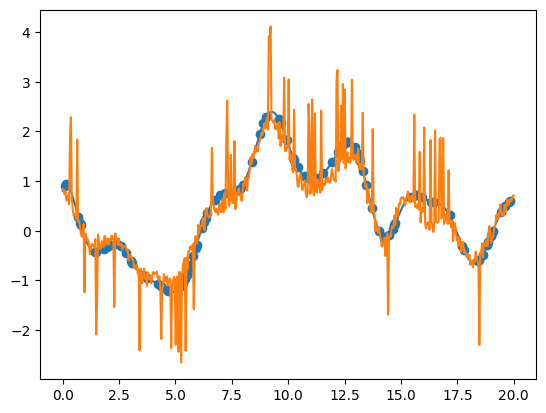

In [20]:
plt.plot(X,f)
plt.plot(X,y)
plt.scatter(Z,model.mu_u)

Laplace loss

Student loss

this is the one with sigma**2 outside the loop

In [21]:
     
import time
import gpflow
import tensorflow as tf
import tensorflow_probability as tfp

class GVI_GP_T(gpflow.models.BayesianModel):
    def __init__(self, X, y,inducing, alpha=0.5,nu=2):
        super().__init__()
        self.X = X
        self.y = y

        self.alpha = gpflow.Parameter(alpha,trainable=False)

        # GP parameters
        self.variance = gpflow.Parameter(1., transform=gpflow.utilities.positive())
        self.lengthscale = gpflow.Parameter(1., transform=gpflow.utilities.positive())
        self.inducing_variable = tf.cast(inducing, tf.float64)
        self.sigma=gpflow.Parameter(1.,trainable=False)
        
        self.nu=tf.constant(nu,dtype=tf.float64)
        self.lambda_inv=tf.Variable([1.]*X.shape[0],trainable=False,dtype=tf.float64)
        self.optimizer = tf.keras.optimizers.Adam(learning_rate=0.01)

    def stable_solve(self, mat, rhs):
        jitter = tf.eye(tf.shape(mat)[0], dtype=mat.dtype) * 1e-6
        L = tf.linalg.cholesky(mat + jitter)
        return tf.linalg.cholesky_solve(L, rhs)
    
    
    @tf.function
    def update_mu_f(self, Sigma_a_inv,Lambda_inv):
        q1 = tf.linalg.inv(self.alpha * Sigma_a_inv + Lambda_inv)
        q2 = tf.matmul(Lambda_inv , self.y)
        return tf.matmul(q1, q2)
    
    def maximum_log_likelihood_objective(self):
        pass
    
    def predict_in(self):
        kernel = tfp.math.psd_kernels.ExponentiatedQuadratic(self.variance, self.lengthscale)
        K = kernel.matrix(self.X, self.X)
        K_uu = kernel.matrix(self.inducing_variable,self.inducing_variable)
        K_uf = kernel.matrix(self.inducing_variable, X)
        K_fu = tf.transpose(K_uf)

        K_uu_inv=tf.linalg.inv(K_uu+tf.linalg.eye(K_uu.shape[0],dtype=tf.float64)*gpflow.default_jitter())

        Sigma_f = K_fu @ K_uu_inv @ K_uf
        
        N = tf.cast(tf.shape(K)[0],tf.float64)
        print(N.dtype)
        identity = tf.eye(N, dtype=K.dtype)
        jitter = identity * 1e-6
        K_j = K + jitter

        Lambda_inv=tf.linalg.diag(self.lambda_inv)
        Sigma_a = self.alpha * K_j + (1.0 - self.alpha) * Sigma_f
        Sigma_a_inv = tf.linalg.inv(Sigma_a + jitter)
        self.mu_f = self.update_mu_f(Sigma_a_inv,Lambda_inv)
        self.Sigma_f=Sigma_f
        
    def predict_out(self,X):
        kernel = tfp.math.psd_kernels.ExponentiatedQuadratic(self.variance, self.lengthscale)
        K_xold_xold = kernel.matrix(self.X, self.X)
        K_xold_xnew = kernel.matrix(X, self.X)
        jitter = 1e-6 * tf.eye(tf.shape(K_xold_xold)[0], dtype=K_xold_xold.dtype)
        K_inv = tf.linalg.inv(K_xold_xold + jitter)

        #compute variance
        f_var = kernel.matrix(X,X) - K_xold_xnew @ K_inv @ tf.transpose(K_xold_xnew)+ K_xold_xnew @ K_inv @ self.Sigma_f @ K_inv @ tf.transpose(K_xold_xnew)
        return K_xold_xnew @ K_inv @ self.mu_f, tf.linalg.diag_part(f_var)
    
    @tf.function
    def train_step(self):
        with tf.GradientTape() as tape:
            kernel = tfp.math.psd_kernels.ExponentiatedQuadratic(self.variance, self.lengthscale)
            K = kernel.matrix(self.X, self.X)
            K_uu = kernel.matrix(self.inducing_variable,self.inducing_variable)
            K_uf = kernel.matrix(self.inducing_variable, X)
            K_fu = tf.transpose(K_uf)

            K_uu_inv=tf.linalg.inv(K_uu+tf.linalg.eye(K_uu.shape[0],dtype=tf.float64)*gpflow.default_jitter())

            Sigma_f = K_fu @ K_uu_inv @ K_uf
            
            N = tf.cast(tf.shape(K)[0],tf.float64)
            print(N.dtype)
            identity = tf.eye(N, dtype=K.dtype)
            jitter = identity * 1e-6
            K_j = K + jitter

            Lambda_inv=tf.linalg.diag(self.lambda_inv)
            Sigma_a = self.alpha * K_j + (1.0 - self.alpha) * Sigma_f
            Sigma_a_inv = tf.linalg.inv(Sigma_a + jitter)
            mu_f = self.update_mu_f(Sigma_a_inv,Lambda_inv)

            # Log-determinants
            ld_Sig_a = tf.linalg.logdet(Sigma_a + jitter)
            ld_Sig_f = tf.linalg.logdet(Sigma_f + jitter)
            ld_K = tf.linalg.logdet(K_j)

            # Loss terms
            term1 = 0.5 *  tf.transpose(mu_f) @ (Lambda_inv+Sigma_a_inv) @ mu_f
            term2 = -  tf.transpose(mu_f) @Lambda_inv @ (self.y)
            term4 = 0.5 * self.sigma**(-2) * tf.linalg.trace(Lambda_inv @ Sigma_f)
            term5 = -1.0 / (2.0 * (self.alpha - 1.0)) * (ld_Sig_a + (self.alpha - 1.0) * ld_Sig_f - self.alpha * ld_K)
            loss = tf.squeeze(term1 + term2 + term4 + term5)

        # Trainable parameters
        

        grads = tape.gradient(loss, self.trainable_variables)
        self.optimizer.apply_gradients(zip(grads,  self.trainable_variables))

        # Update Lambda using current mu_f
        residual = self.y - mu_f
        num=self.nu+1
        denom=self.nu*self.sigma**2+tf.squeeze(residual)**2+tf.linalg.diag_part(Sigma_f)
        self.lambda_inv.assign(tf.squeeze((num / denom)))
         
        return loss
    
    def predict(self):
        kernel = tfp.math.psd_kernels.ExponentiatedQuadratic(self.variance, self.lengthscale)
        K = kernel.matrix(self.X, self.X)
        K_uu = kernel.matrix(self.inducing_variable,self.inducing_variable)
        K_uf = kernel.matrix(self.inducing_variable, X)
        K_fu = tf.transpose(K_uf)

        K_uu_inv=tf.linalg.inv(K_uu+tf.linalg.eye(K_uu.shape[0],dtype=tf.float64)*gpflow.default_jitter())

        Sigma_f = K_fu @ K_uu_inv @ K_uf
        N = tf.cast(tf.shape(K)[0],tf.float64)
        identity = tf.eye(N, dtype=K.dtype)
        jitter = identity * 1e-6
        K_j = K + jitter

        Lambda_inv=tf.linalg.diag(self.lambda_inv)
        Sigma_a = self.alpha * K_j + (1.0 - self.alpha) * Sigma_f
        Sigma_a_inv = tf.linalg.inv(Sigma_a + jitter)
        mu_f = self.update_mu_f(Sigma_a_inv, self.sigma**2,Lambda_inv)
        return mu_f,Sigma_f

    def train(self, max_steps=500, tolerance=0.5, patience=5):
        loss_history = []
        steps_without_improvement = 0
        start_time = time.time()

        for step in range(max_steps):
            loss_val = self.train_step()
            loss_val = loss_val.numpy()
            loss_history.append(loss_val)

            tf.print("Step:", step, "Loss:", loss_val)

            if step > 0:
                loss_diff = abs(loss_history[-1] - loss_history[-2])
                if loss_diff < tolerance:
                    steps_without_improvement += 1
                else:
                    steps_without_improvement = 0

                if steps_without_improvement >= patience:
                    print(f"Early stopping at step {step}: loss change < {tolerance} for {patience} steps.")
                    break
        end_time = time.time()
        elapsed = end_time - start_time
        print(f"Training completed in {elapsed:.3f} seconds.")      

N=X.shape[0]
Z = X[np.random.choice(N, 70, replace=False), :]
inducing_variable = gpflow.Parameter(Z,trainable=True)
model = GVI_GP_T(X, y,inducing_variable)
model.train()

<dtype: 'float64'>
<dtype: 'float64'>
Step: 0 Loss: 192.6290315855941
Step: 1 Loss: 215.12469810218334
Step: 2 Loss: 214.28114464509625
Step: 3 Loss: 211.6676716208968
Step: 4 Loss: 208.87213073030196
Step: 5 Loss: 206.06755278778692
Step: 6 Loss: 203.27278513673227
Step: 7 Loss: 200.49078583264506
Step: 8 Loss: 197.72266188562475
Step: 9 Loss: 194.96785775529113
Step: 10 Loss: 192.2269377122677
Step: 11 Loss: 189.5002842515079
Step: 12 Loss: 186.7880503447257
Step: 13 Loss: 184.09022433535387
Step: 14 Loss: 181.40718290444644
Step: 15 Loss: 178.7395161572118
Step: 16 Loss: 176.08716598003994
Step: 17 Loss: 173.45044315428433
Step: 18 Loss: 170.8295948837791
Step: 19 Loss: 168.22444196719727
Step: 20 Loss: 165.63563861425945
Step: 21 Loss: 163.0631520698731
Step: 22 Loss: 160.50781343304513
Step: 23 Loss: 157.96942547414113
Step: 24 Loss: 155.4489527321655
Step: 25 Loss: 152.9469115854805
Step: 26 Loss: 150.46336480926158
Step: 27 Loss: 147.99952858847215
Step: 28 Loss: 145.55551231183

<dtype: 'float64'>


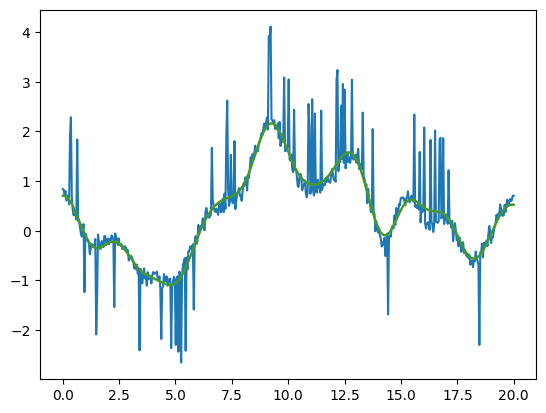

In [22]:
model.predict_in()
plt.plot(X,y)
plt.plot(X,model.mu_f)
plt.plot(X,model.predict_out(X)[0])

In [8]:
     
import time
import gpflow
import tensorflow as tf
import tensorflow_probability as tfp

class GVI_GP_WELSCH(gpflow.models.BayesianModel):
    def __init__(self, X, y,inducing, alpha=0.5,c_prop=2.5):
        super().__init__()
        self.X = X
        self.y = y

        self.alpha = gpflow.Parameter(alpha,trainable=False)
        self.c=tf.Variable(c_prop*tf.reduce_mean(self.y**2),dtype=tf.float64,trainable=False)
        self.c_prop=c_prop
        
        # GP parameters
        self.variance = gpflow.Parameter(1., transform=gpflow.utilities.positive())
        self.lengthscale = gpflow.Parameter(1., transform=gpflow.utilities.positive())
        self.inducing_variable = inducing
        self.mu_f = tf.Variable(tf.ones(self.y.shape, dtype=tf.float64),trainable=False)
        #self.mu_f=tf.reshape(self.mu_f, [-1, 1])
        print(self.mu_f.shape)
        
        self.optimizer = tf.keras.optimizers.Adam(learning_rate=0.01)

    def stable_solve(self, mat, rhs):
        jitter = tf.eye(tf.shape(mat)[0], dtype=mat.dtype) * 1e-6
        L = tf.linalg.cholesky(mat + jitter)
        return tf.linalg.cholesky_solve(L, rhs)
    
    
    def maximum_log_likelihood_objective(self):
        pass
    
    @tf.function
    def train_step(self):
        with tf.GradientTape() as tape:
            kernel = tfp.math.psd_kernels.ExponentiatedQuadratic(self.variance, self.lengthscale)
            K = kernel.matrix(self.X, self.X)
            K_uu = kernel.matrix(self.inducing_variable,self.inducing_variable)
            K_uf = kernel.matrix(self.inducing_variable, X)
            K_fu = tf.transpose(K_uf)

            K_uu_inv=tf.linalg.inv(K_uu+tf.linalg.eye(K_uu.shape[0],dtype=tf.float64)*gpflow.default_jitter())

            Sigma_f = K_fu @ K_uu_inv @ K_uf
            sigma_f=tf.linalg.diag_part(Sigma_f)
            
            N = tf.cast(tf.shape(K)[0],tf.float64)
            print(N.dtype)
            identity = tf.eye(N, dtype=K.dtype)
            jitter = identity * 1e-6
            K_j = K + jitter

            Sigma_a = self.alpha * K_j + (1.0 - self.alpha) * Sigma_f
            Sigma_a_inv = tf.linalg.inv(Sigma_a + jitter)
            
            # Log-determinants
            ld_Sig_a = tf.linalg.logdet(Sigma_a + jitter)
            ld_Sig_f = tf.linalg.logdet(Sigma_f + jitter)
            ld_K = tf.linalg.logdet(K_j)

            # Loss terms
            term1 = tf.reduce_sum(self.c/2*(1-1/tf.math.sqrt(1+2*sigma_f/self.c**2)*tf.math.exp(-(self.mu_f-self.y)**2/(self.c**2+2*sigma_f))))
            term2 = self.alpha/2*tf.transpose(self.mu_f)@Sigma_a_inv@self.mu_f
            term3 = -1.0 / (2.0 * (self.alpha - 1.0)) * (ld_Sig_a + (self.alpha - 1.0) * ld_Sig_f - self.alpha * ld_K)
            loss = tf.squeeze(term1 + term2  + term3)
        
        # Trainable parameters
        

        grads = tape.gradient(loss, self.trainable_variables)
        self.optimizer.apply_gradients(zip(grads,  self.trainable_variables))
        #self.c.assign(tf.sqrt(self.c_prop*tf.reduce_mean((self.y-self.mu_f)**2/sigma_f)))
        return loss,Sigma_a, sigma_f 
    
    def predict(self,X_new):
        kernel = tfp.math.psd_kernels.ExponentiatedQuadratic(self.variance, self.lengthscale)
        K = kernel.matrix(self.X, self.X)
        K_uu = kernel.matrix(self.inducing_variable,self.inducing_variable)
        K_uf = kernel.matrix(self.inducing_variable, X)
        K_fu = tf.transpose(K_uf)
        K_x_xnew=kernel.matrix( X_new,self.X)

        K_uu_inv=tf.linalg.inv(K_uu+tf.linalg.eye(K_uu.shape[0],dtype=tf.float64)*gpflow.default_jitter())

        Sigma_f = K_fu @ K_uu_inv @ K_uf
        
        return K_x_xnew@tf.linalg.inv(K)@self.mu_f

    def train(self, max_steps=100, tolerance=0.00001, patience=5):
        loss_history = []
        steps_without_improvement = 0
        start_time = time.time()

        for step in range(max_steps):
            loss_val,Sigma_a, sigma_f = self.train_step()
        
            while True:
                old=self.mu_f
                quant = (
                    (self.c ** 2 / 2 * (1 - 1 / tf.sqrt(1 + 2 * sigma_f / self.c ** 2)
                     * tf.exp(-tf.squeeze(self.mu_f - self.y) ** 2 / (self.c ** 2 + 2 * sigma_f))))
                )
                quant = quant * -2 / (self.c ** 2 + 2 * sigma_f)
                D = tf.linalg.diag(tf.squeeze(quant))
                self.mu_f.assign(Sigma_a @ tf.linalg.inv(D + Sigma_a) @ self.y)
                if tf.reduce_mean(tf.abs(old-self.mu_f)/(tf.abs(old+self.mu_f)/2))<0.01:
                    break

            loss_val = loss_val.numpy()
            loss_history.append(loss_val)

            tf.print("Step:", step, "Loss:", loss_val)

            if step > 0:
                loss_diff = abs(loss_history[-1] - loss_history[-2])/abs(loss_history[-1]+ loss_history[-2])
                if loss_diff < tolerance:
                    steps_without_improvement += 1
                else:
                    steps_without_improvement = 0

                if steps_without_improvement >= patience:
                    print(f"Early stopping at step {step}: loss change < {tolerance} for {patience} steps.")
                    break
        end_time = time.time()
        elapsed = end_time - start_time
        print(f"Training completed in {elapsed:.3f} seconds.")      

N=X.shape[0]
Z = X[np.random.choice(N, 50, replace=False), :]
inducing_variable = gpflow.Parameter(Z,trainable=True)
model = GVI_GP_WELSCH(X, y,inducing_variable)
model.train(max_steps=1000)

(500, 1)
<dtype: 'float64'>
<dtype: 'float64'>
Step: 0 Loss: 72496.03333419353
Step: 1 Loss: 61546.56770737982
Step: 2 Loss: 114114.78329479726
Step: 3 Loss: 43591.14322963068
Step: 4 Loss: 44568.48207192257
Step: 5 Loss: 672129.1484151897
Step: 6 Loss: 327077.1283546961
Step: 7 Loss: 48791.41928367932
Step: 8 Loss: 41180.90913580045
Step: 9 Loss: 40663.01058321817
Step: 10 Loss: 40619.35713463862
Step: 11 Loss: 40964.74230944968
Step: 12 Loss: 40944.59309120595
Step: 13 Loss: 41397.00982601733
Step: 14 Loss: 40967.46271663894
Step: 15 Loss: 43002.76093198456
Step: 16 Loss: 40164.37715810394
Step: 17 Loss: 214055.99169307263
Step: 18 Loss: 44360.89465113898
Step: 19 Loss: 42015.01317629707
Step: 20 Loss: 41211.561469300956
Step: 21 Loss: 110825.75638748593
Step: 22 Loss: 43321.756807710335
Step: 23 Loss: 43439.3936747859
Step: 24 Loss: 39589.88551397869
Step: 25 Loss: 42866.626706571165
Step: 26 Loss: 58164.85447641739
Step: 27 Loss: 39253.294449655295
Step: 28 Loss: 41500.292747126165

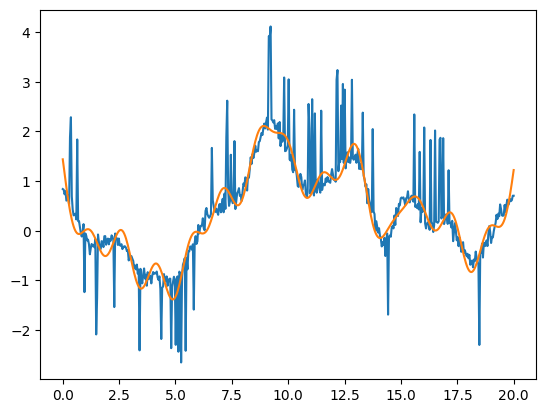

In [9]:
plt.plot(X,y)
plt.plot(X,model.mu_f)

In [12]:
     
import time
import gpflow
import tensorflow as tf
import tensorflow_probability as tfp

class GVI_SGP_WELSCH(gpflow.models.BayesianModel):
    def __init__(self, X, y,inducing,kernel,structure="Tri", alpha=0.5,c_prop=2.5):
        super().__init__()
        self.X = X
        self.y = y
        self.N_u = inducing.shape[0]

        self.alpha = gpflow.Parameter(alpha,trainable=False)
        self.c=tf.Variable(tf.sqrt(c_prop*tf.reduce_mean(self.y**2)),dtype=tf.float64,trainable=False)
        self.c_prop=c_prop
        
        if structure == "Diag":
            self.Var_q = gpflow.Parameter([1.] * self.N_u, transform=gpflow.utilities.positive())
        else:
            self.Var_q = gpflow.Parameter(tf.linalg.eye(self.N_u), transform=gpflow.utilities.triangular())
        # GP parameters
        self.kernel = kernel
        self.inducing_variable = inducing
        self.mu_u = tf.Variable(tf.ones((self.N_u, 1), dtype=tf.float64))
        self.structure=structure

        
        self.optimizer = tf.keras.optimizers.Adam(learning_rate=0.01)

    def stable_solve(self, mat, rhs):
        jitter = tf.eye(tf.shape(mat)[0], dtype=mat.dtype) * 1e-6
        L = tf.linalg.cholesky(mat + jitter)
        return tf.linalg.cholesky_solve(L, rhs)
    
    
    def maximum_log_likelihood_objective(self):
        pass
    
    @tf.function
    def train_step(self):
        with tf.GradientTape() as tape:
            K = self.kernel(self.X, self.X)
            K_uu = self.kernel(self.inducing_variable,self.inducing_variable)
            K_uf = self.kernel(self.inducing_variable, X)
            K_fu = tf.transpose(K_uf)

            K_uu_inv=tf.linalg.inv(K_uu+tf.linalg.eye(K_uu.shape[0],dtype=tf.float64)*gpflow.default_jitter())
            
            if self.structure == "Diag":
                Sigma_u = tf.linalg.diag(self.Var_q)
            else:
                Sigma_u = self.Var_q @ tf.transpose(self.Var_q)
            
            identity = tf.eye(self.N_u, dtype=K.dtype)
            jitter = identity * 1e-6

            Sigma_a = self.alpha * K_uu + (1.0 - self.alpha) * Sigma_u
            Sigma_a_inv = tf.linalg.inv(Sigma_a + jitter)

            # Log-determinants
            ld_Sig_a = tf.linalg.logdet(Sigma_a + jitter)
            ld_Sig_f = tf.linalg.logdet(Sigma_u + jitter)
            ld_K = tf.linalg.logdet(K_uu+jitter)
            
            sigma_f=tf.linalg.diag_part(K-K_fu@K_uu_inv@K_uf+K_fu@K_uu_inv@Sigma_u@K_uu_inv@K_uf)
            mu_f=K_fu@K_uu_inv@self.mu_u

            # Loss terms
            term1 = tf.reduce_sum(self.c/2*(1-1/tf.math.sqrt(1+2*sigma_f/self.c**2)*tf.math.exp(-(mu_f-self.y)**2/(self.c**2+2*sigma_f))))
            term2 = self.alpha/2*tf.transpose(self.mu_u)@Sigma_a_inv@self.mu_u
            term3 = -1.0 / (2.0 * (self.alpha - 1.0)) * (ld_Sig_a + (self.alpha - 1.0) * ld_Sig_f - self.alpha * ld_K)
            loss = tf.squeeze(term1 + term2  + term3)
        
        # Trainable parameters
        grads = tape.gradient(loss, self.trainable_variables)
        self.optimizer.apply_gradients(zip(grads,  self.trainable_variables))
        #self.c.assign(tf.sqrt(self.c_prop*tf.reduce_mean((self.y-mu_f)**2/sigma_f)))
        return loss
    

    def train(self, max_steps=100, tolerance=0.00001, patience=5):
        loss_history = []
        steps_without_improvement = 0
        start_time = time.time()

        for step in range(max_steps):
            loss_val = self.train_step()
        
            loss_val = loss_val.numpy()
            loss_history.append(loss_val)

            tf.print("Step:", step, "Loss:", loss_val)

            if step > 0:
                loss_diff = abs(loss_history[-1] - loss_history[-2])/abs(loss_history[-1]+ loss_history[-2])
                if loss_diff < tolerance:
                    steps_without_improvement += 1
                else:
                    steps_without_improvement = 0

                if steps_without_improvement >= patience:
                    print(f"Early stopping at step {step}: loss change < {tolerance} for {patience} steps.")
                    break
        end_time = time.time()
        elapsed = end_time - start_time
        print(f"Training completed in {elapsed:.3f} seconds.")      
    def predict_out(self, Xnew):
        if self.structure == "Diag":
            Sigma_u = tf.linalg.diag(self.Var_q)
        else:
            Sigma_u = self.Var_q @ tf.transpose(self.Var_q)
        K_uu = self.kernel(self.inducing_variable, self.inducing_variable)
        K_xu = self.kernel(Xnew, self.inducing_variable)
        I_M = tf.eye(self.N_u, dtype=tf.float64)
        K_uu_inv = self.stable_solve(K_uu, I_M)

        f_var = self.kernel(Xnew, Xnew) - K_xu @ K_uu_inv @ tf.transpose(K_xu) + K_xu @ K_uu_inv @ Sigma_u @ K_uu_inv @ tf.transpose(K_xu)

        return K_xu @ K_uu_inv @ self.mu_u, tf.linalg.diag_part(f_var)

    
N=X.shape[0]
Z = X[np.random.choice(N, 50, replace=False), :]
inducing_variable = gpflow.Parameter(Z,trainable=False)
kernel = gpflow.kernels.SquaredExponential(lengthscales=1.0, variance=1.0)
model = GVI_SGP_WELSCH(X, y,inducing_variable,kernel)
model.train(max_steps=1500)
#opt = gpflow.optimizers.Scipy()
#opt.minimize(model.train_step, model.trainable_variables)

Step: 0 Loss: 103430.01094964422
Step: 1 Loss: 101667.40484226501
Step: 2 Loss: 99663.11980888016
Step: 3 Loss: 97914.78102069553
Step: 4 Loss: 96279.47345678193
Step: 5 Loss: 94652.12384793856
Step: 6 Loss: 93122.14784238809
Step: 7 Loss: 91728.0095366077
Step: 8 Loss: 90384.62624963564
Step: 9 Loss: 89044.51021892413
Step: 10 Loss: 87736.60473266122
Step: 11 Loss: 86488.9530577054
Step: 12 Loss: 85278.2950708128
Step: 13 Loss: 84073.45341547568
Step: 14 Loss: 82878.1261279656
Step: 15 Loss: 81714.71125436838
Step: 16 Loss: 80588.3002101729
Step: 17 Loss: 79484.67793098277
Step: 18 Loss: 78395.52430704236
Step: 19 Loss: 77326.52910663735
Step: 20 Loss: 76283.00286403554
Step: 21 Loss: 75258.42925090826
Step: 22 Loss: 74241.05092372325
Step: 23 Loss: 73227.9557798192
Step: 24 Loss: 72225.0355667606
Step: 25 Loss: 71238.42052263764
Step: 26 Loss: 70267.99999832147
Step: 27 Loss: 69310.66827806507
Step: 28 Loss: 68369.23352654128
Step: 29 Loss: 67448.87386771497
Step: 30 Loss: 66552.0957

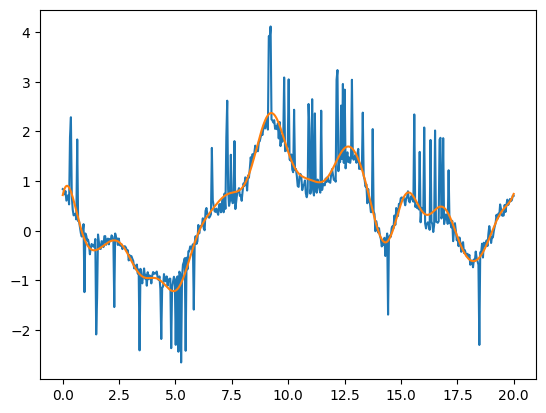

In [13]:
mu,s=model.predict_out(X)

plt.plot(X,y)


plt.plot(X,mu)

In [25]:
     
import time
import gpflow
import tensorflow as tf
import tensorflow_probability as tfp
tfpk = tfp.math.psd_kernels

class GVI_SGP_T(gpflow.models.BayesianModel):
    def __init__(self, X, y,inducing,kernel,structure="Tri", alpha=0.5,nu=2):
        super().__init__()
        self.X = X
        self.y = y

        self.alpha = gpflow.Parameter(alpha,trainable=False)
        self.inducing_variable = inducing
        self.N_u = inducing.shape[0]
        self.sigma=gpflow.Parameter(1.,trainable=False)
        
        self.nu=tf.constant(nu,dtype=tf.float64)
        self.lambda_inv=tf.Variable([1.]*X.shape[0],trainable=False,dtype=tf.float64)
        # Variational parameters
        self.alpha = gpflow.Parameter(alpha, trainable=False, dtype=tf.float64)
        if structure == "Diag":
            self.Var_q = gpflow.Parameter([1.] * self.N_u, transform=gpflow.utilities.positive())
        else:
            self.Var_q = gpflow.Parameter(tf.linalg.eye(self.N_u), transform=gpflow.utilities.triangular())
        self.structure = structure
        self.kernel = kernel
        
        self.optimizer = tf.keras.optimizers.Adam(learning_rate=0.01)

    def stable_solve(self, mat, rhs):
        jitter = tf.eye(tf.shape(mat)[0], dtype=mat.dtype) * 1e-6
        L = tf.linalg.cholesky(mat + jitter)
        return tf.linalg.cholesky_solve(L, rhs)
    
    
    def maximum_log_likelihood_objective(self):
        pass
    
    def predict_in(self):
        K_uu = self.kernel(self.inducing_variable,self.inducing_variable)
        K_uf = self.kernel(self.inducing_variable, X)
        K_fu = tf.transpose(K_uf)

        Lambda_inv=tf.linalg.diag(self.lambda_inv)
        jitter = tf.eye(self.N_u, dtype=tf.float64) * 1e-6
        K_uu_inv = tf.linalg.inv(K_uu + jitter)

        if self.structure == "Diag":
            Sigma_u = tf.linalg.diag(self.Var_q)
        else:
            Sigma_u = self.Var_q @ tf.transpose(self.Var_q)
        Sigma_a = self.alpha * K_uu + (1.0 - self.alpha) * Sigma_u
        Sigma_a_inv = tf.linalg.inv(Sigma_a + jitter)

        precision_mid = self.alpha * Sigma_a_inv + (
                        K_uu_inv @ K_uf @ Lambda_inv @ K_fu @ K_uu_inv) 
        q1 = tf.linalg.inv(precision_mid + jitter)
        q2 = tf.matmul(K_uu_inv @ K_uf, Lambda_inv@ (self.y))

        self.mu_u = tf.matmul(q1, q2)
        self.Sigma_u = Sigma_u
        
    def predict_out(self, Xnew):
        K_uu = self.kernel(self.inducing_variable, self.inducing_variable)
        K_xu = self.kernel(Xnew, self.inducing_variable)
        I_M = tf.eye(self.N_u, dtype=tf.float64)
        K_uu_inv = self.stable_solve(K_uu, I_M)

        f_var = self.kernel(Xnew, Xnew) - K_xu @ K_uu_inv @ tf.transpose(K_xu) + K_xu @ K_uu_inv @ self.Sigma_u @ K_uu_inv @ tf.transpose(K_xu)

        return K_xu @ K_uu_inv @ self.mu_u, tf.linalg.diag_part(f_var)
        
    
    @tf.function
    def train_step(self):
        with tf.GradientTape() as tape:
            K = self.kernel(self.X, self.X)
            K_uu = self.kernel(self.inducing_variable,self.inducing_variable)
            K_uf = self.kernel(self.inducing_variable, X)
            K_fu = tf.transpose(K_uf)

            K_uu_inv=tf.linalg.inv(K_uu+tf.linalg.eye(K_uu.shape[0],dtype=tf.float64)*gpflow.default_jitter())
            
            if self.structure == "Diag":
                Sigma_u = tf.linalg.diag(self.Var_q)
            else:
                Sigma_u = self.Var_q @ tf.transpose(self.Var_q)
            
            identity = tf.eye(self.N_u, dtype=K.dtype)
            jitter = identity * 1e-6

            Lambda_inv=tf.linalg.diag(self.lambda_inv)
            Sigma_a = self.alpha * K_uu + (1.0 - self.alpha) * Sigma_u
            Sigma_a_inv = tf.linalg.inv(Sigma_a + jitter)
            
            precision_mid = self.alpha * Sigma_a_inv + (
                        K_uu_inv @ K_uf @ Lambda_inv @ K_fu @ K_uu_inv)
            q1 = tf.linalg.inv(precision_mid + jitter)
            q2 = tf.matmul(K_uu_inv @ K_uf, Lambda_inv @ self.y) 
            mu_u = tf.matmul(q1, q2)

            # Log-determinants
            ld_Sig_a = tf.linalg.logdet(Sigma_a + jitter)
            ld_Sig_f = tf.linalg.logdet(Sigma_u + jitter)
            ld_K = tf.linalg.logdet(K_uu+jitter)

            # Loss terms
            term1 = 0.5 *  tf.transpose(mu_u) @ (K_uu_inv @ K_uf @ Lambda_inv @ K_fu @ K_uu_inv+Sigma_a_inv) @ mu_u
            term2 = -  tf.transpose(mu_u)@K_uu_inv@K_uf@ Lambda_inv @ (self.y)
            term4 = 0.5  * tf.linalg.trace(K_uu_inv @ K_uf @ Lambda_inv @ K_fu @ K_uu_inv @ Sigma_u)
            term5 = -1.0 / (2.0 * (self.alpha - 1.0)) * (ld_Sig_a + (self.alpha - 1.0) * ld_Sig_f - self.alpha * ld_K)
            loss = tf.squeeze(term1 + term2 + term4 + term5)

        # Trainable parameters
        

        grads = tape.gradient(loss, self.trainable_variables)
        self.optimizer.apply_gradients(zip(grads,  self.trainable_variables))

        # Update Lambda using current mu_f
        residual = self.y - K_fu@K_uu_inv@mu_u 
        num=self.nu+1
        denom=self.nu*self.sigma**2+tf.squeeze(residual)**2+tf.linalg.diag_part(K_fu@K_uu_inv@Sigma_u@K_uu_inv@K_uf)
        self.lambda_inv.assign(tf.squeeze((num / denom)))
         
        return loss
    
    def predict(self):
        kernel = tfp.math.psd_kernels.ExponentiatedQuadratic(self.variance, self.lengthscale)
        K = kernel.matrix(self.X, self.X)
        K_uu = kernel.matrix(self.inducing_variable,self.inducing_variable)
        K_uf = kernel.matrix(self.inducing_variable, X)
        K_fu = tf.transpose(K_uf)

        K_uu_inv=tf.linalg.inv(K_uu+tf.linalg.eye(K_uu.shape[0],dtype=tf.float64)*gpflow.default_jitter())

        Sigma_f = K_fu @ K_uu_inv @ K_uf
        N = tf.cast(tf.shape(K)[0],tf.float64)
        identity = tf.eye(N, dtype=K.dtype)
        jitter = identity * 1e-6
        K_j = K + jitter

        Lambda_inv=tf.linalg.diag(self.lambda_inv)
        Sigma_a = self.alpha * K_j + (1.0 - self.alpha) * Sigma_f
        Sigma_a_inv = tf.linalg.inv(Sigma_a + jitter)
        mu_f = self.update_mu_f(Sigma_a_inv, self.sigma**2,Lambda_inv)
        return mu_f,Sigma_f

    def train(self, max_steps=500, tolerance=0.5, patience=5):
        loss_history = []
        steps_without_improvement = 0
        start_time = time.time()

        for step in range(max_steps):
            loss_val = self.train_step()
            loss_val = loss_val.numpy()
            loss_history.append(loss_val)

            tf.print("Step:", step, "Loss:", loss_val)

            if step > 0:
                loss_diff = abs(loss_history[-1] - loss_history[-2])
                if loss_diff < tolerance:
                    steps_without_improvement += 1
                else:
                    steps_without_improvement = 0

                if steps_without_improvement >= patience:
                    print(f"Early stopping at step {step}: loss change < {tolerance} for {patience} steps.")
                    break
        end_time = time.time()
        elapsed = end_time - start_time
        print(f"Training completed in {elapsed:.3f} seconds.")      

N=X.shape[0]
Z = X[np.random.choice(N, 70, replace=False), :]
inducing_variable = gpflow.Parameter(Z,trainable=False)
kernel = gpflow.kernels.SquaredExponential(lengthscales=1.0, variance=1.0)
model = GVI_SGP_T(X, y,inducing_variable,kernel)
model.train()

Step: 0 Loss: 55202.134223359084
Step: 1 Loss: 317.26250598918887
Step: 2 Loss: 316.1779480134608
Step: 3 Loss: 312.2420694529874
Step: 4 Loss: 307.7394590916376
Step: 5 Loss: 303.0533466822702
Step: 6 Loss: 298.28259577794734
Step: 7 Loss: 293.4932111471887
Step: 8 Loss: 288.7321958596442
Step: 9 Loss: 284.00834079249813
Step: 10 Loss: 279.31522330005635
Step: 11 Loss: 274.6441832188721
Step: 12 Loss: 269.9873146169706
Step: 13 Loss: 265.3455183531246
Step: 14 Loss: 260.7313175567418
Step: 15 Loss: 256.15199319648207
Step: 16 Loss: 251.59744575589346
Step: 17 Loss: 247.06574641700283
Step: 18 Loss: 242.57669909246889
Step: 19 Loss: 238.14588117959002
Step: 20 Loss: 233.77118158314806
Step: 21 Loss: 229.46034120548822
Step: 22 Loss: 225.23853923098886
Step: 23 Loss: 221.11762821702985
Step: 24 Loss: 217.087975769546
Step: 25 Loss: 213.14029516845258
Step: 26 Loss: 209.27213023330023
Step: 27 Loss: 205.4744452729667
Step: 28 Loss: 201.73871495218552
Step: 29 Loss: 198.07669822192008
Ste

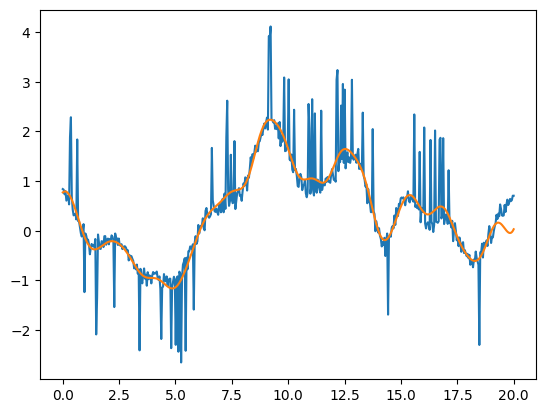

In [26]:
plt.plot(X,y)
model.predict_in()
plt.plot(X,model.predict_out(X)[0])

Now we go with the AL

In [27]:
     
import time
import gpflow
import tensorflow as tf
import tensorflow_probability as tfp

class GVI_GP_L(gpflow.models.BayesianModel):
    def __init__(self, X, y,inducing,kernel,Sigma_f_structure="c_f", alpha=0.5):
        super().__init__()
        self.X = X
        self.y = y

        self.alpha = gpflow.Parameter(alpha,trainable=False)

        # GP parameters
        self.kernel = kernel
        self.inducing_variable = inducing
        self.b=gpflow.Parameter(1.,transform=gpflow.utilities.positive())
        if Sigma_f_structure == "c_f":
            self.c_f = gpflow.Parameter(1., transform=gpflow.utilities.positive(), trainable=True)
        self.Sigma_f_structure = Sigma_f_structure

        self.lambda_inv=tf.Variable([1.]*X.shape[0],trainable=False,dtype=tf.float64)
        self.optimizer = tf.keras.optimizers.Adam(learning_rate=0.01)

    def stable_solve(self, mat, rhs):
        jitter = tf.eye(tf.shape(mat)[0], dtype=mat.dtype) * 1e-6
        L = tf.linalg.cholesky(mat + jitter)
        return tf.linalg.cholesky_solve(L, rhs)
    
    
    @tf.function
    def update_mu_f(self, Sigma_a_inv, sigma_2,Lambda_inv):
        q1 = tf.linalg.inv(self.alpha * Sigma_a_inv + Lambda_inv / sigma_2)
        q2 = tf.matmul(Lambda_inv / sigma_2, self.y)
        return tf.matmul(q1, q2)
    
    def maximum_log_likelihood_objective(self):
        pass
        
    @tf.function
    def compute_sigma_f(self, X,Lambda_inv):
        if self.Sigma_f_structure == "c_f":
            K = self.kernel(X, X)
            Sigma_f = self.c_f * K @ tf.linalg.inv(
                    K + Lambda_inv*self.b**2) @Lambda_inv * self.b ** 2 
        else:
            K = self.kernel(X, X)
            K_uu = self.kernel(self.inducing_variable, self.inducing_variable)
            K_uf = self.kernel(self.inducing_variable, X)
            K_fu = tf.transpose(K_uf)
            K_uu_inv = tf.linalg.inv(K_uu + tf.linalg.eye(K_uu.shape[0], dtype=tf.float64) * gpflow.default_jitter())
            Sigma_f = K_fu @ K_uu_inv @ K_uf
        return K, Sigma_f
    
    def predict_in(self):
        K = self.kernel(self.X, self.X)
        K_uu = self.kernel(self.inducing_variable,self.inducing_variable)
        K_uf = self.kernel(self.inducing_variable, X)
        K_fu = tf.transpose(K_uf)

        K_uu_inv=tf.linalg.inv(K_uu+tf.linalg.eye(K_uu.shape[0],dtype=tf.float64)*gpflow.default_jitter())

        Sigma_f = K_fu @ K_uu_inv @ K_uf
        
        N = tf.cast(tf.shape(K)[0],tf.float64)
        print(N.dtype)
        identity = tf.eye(N, dtype=K.dtype)
        jitter = identity * 1e-6
        K_j = K + jitter

        Lambda_inv=tf.linalg.diag(self.lambda_inv)
        Sigma_a = self.alpha * K_j + (1.0 - self.alpha) * Sigma_f
        Sigma_a_inv = tf.linalg.inv(Sigma_a + jitter)
        self.mu_f = self.update_mu_f(Sigma_a_inv, self.b**2,Lambda_inv)
        self.Sigma_f=Sigma_f
        
    def predict_out(self,X):
        K_xold_xold = self.kernel(self.X, self.X)
        K_xold_xnew = self.kernel(X, self.X)
        jitter = 1e-6 * tf.eye(tf.shape(K_xold_xold)[0], dtype=K_xold_xold.dtype)
        K_inv = tf.linalg.inv(K_xold_xold + jitter)

        #compute variance
        f_var = self.kernel(X,X) - K_xold_xnew @ K_inv @ tf.transpose(K_xold_xnew)+ K_xold_xnew @ K_inv @ self.Sigma_f @ K_inv @ tf.transpose(K_xold_xnew)
        return K_xold_xnew @ K_inv @ self.mu_f, tf.linalg.diag_part(f_var)
    
    @tf.function
    def train_step(self):
        with tf.GradientTape() as tape:
            K = self.kernel(self.X, self.X)
            K_uu = self.kernel(self.inducing_variable,self.inducing_variable)
            K_uf = self.kernel(self.inducing_variable, X)
            K_fu = tf.transpose(K_uf)

            K_uu_inv=tf.linalg.inv(K_uu+tf.linalg.eye(K_uu.shape[0],dtype=tf.float64)*gpflow.default_jitter())

            Sigma_f = K_fu @ K_uu_inv @ K_uf
            
            N = tf.cast(tf.shape(K)[0],tf.float64)
            print(N.dtype)
            identity = tf.eye(N, dtype=K.dtype)
            jitter = identity * 1e-6
            K_j = K + jitter

            Lambda_inv=tf.linalg.diag(self.lambda_inv)
            Sigma_a = self.alpha * K_j + (1.0 - self.alpha) * Sigma_f
            Sigma_a_inv = tf.linalg.inv(Sigma_a + jitter)
            mu_f = self.update_mu_f(Sigma_a_inv, self.b**2,Lambda_inv)

            # Log-determinants
            ld_Sig_a = tf.linalg.logdet(Sigma_a + jitter)
            ld_Sig_f = tf.linalg.logdet(Sigma_f + jitter)
            ld_K = tf.linalg.logdet(K_j)

            # Loss terms
            term1 = 0.5 * self.b**(-2) * tf.transpose(mu_f) @ (Lambda_inv+Sigma_a_inv) @ mu_f
            term2 = -self.b**(-2) * tf.transpose(mu_f) @Lambda_inv @ (self.y)
            term3 = N* tf.math.log(self.b)
            term4 = 0.5 * self.b**(-2) * tf.linalg.trace(Lambda_inv @ Sigma_f)
            term5 = -1.0 / (2.0 * (self.alpha - 1.0)) * (ld_Sig_a + (self.alpha - 1.0) * ld_Sig_f - self.alpha * ld_K)
            loss = tf.squeeze(term1 + term2  + term3 + term4 + term5)

        # Trainable parameters
        

        grads = tape.gradient(loss, self.trainable_variables)
        self.optimizer.apply_gradients(zip(grads,  self.trainable_variables))

        # Update Lambda using current mu_f
        residual = self.y - mu_f
        denom=tf.squeeze(residual)**2+tf.linalg.diag_part(Sigma_f)
        self.lambda_inv.assign(tf.squeeze((self.b**2 / denom)))
         
        return loss
    
    def train(self, max_steps=500, tolerance=0.5, patience=5):
        loss_history = []
        steps_without_improvement = 0
        start_time = time.time()

        for step in range(max_steps):
            loss_val = self.train_step()
            loss_val = loss_val.numpy()
            loss_history.append(loss_val)

            tf.print("Step:", step, "Loss:", loss_val)

            if step > 0:
                loss_diff = abs(loss_history[-1] - loss_history[-2])
                if loss_diff < tolerance:
                    steps_without_improvement += 1
                else:
                    steps_without_improvement = 0

                if steps_without_improvement >= patience:
                    print(f"Early stopping at step {step}: loss change < {tolerance} for {patience} steps.")
                    break
        end_time = time.time()
        elapsed = end_time - start_time
        print(f"Training completed in {elapsed:.3f} seconds.")      

N=X.shape[0]
Z = X[np.random.choice(N, 70, replace=False), :]
inducing_variable = gpflow.Parameter(Z,trainable=True)
kernel = gpflow.kernels.SquaredExponential(lengthscales=1.0, variance=1.0)
model = GVI_GP_L(X, y,kernel,inducing_variable)
model.train()

<dtype: 'float64'>
<dtype: 'float64'>
Step: 0 Loss: 192.09294776355804
Step: 1 Loss: 227.67291270755294
Step: 2 Loss: 226.99710869091638
Step: 3 Loss: 223.2096200831827
Step: 4 Loss: 218.95965071309575
Step: 5 Loss: 214.637742114111
Step: 6 Loss: 210.29482396196858
Step: 7 Loss: 205.93759951660533
Step: 8 Loss: 201.56660703315174
Step: 9 Loss: 197.18060319914758
Step: 10 Loss: 192.77828557284812
Step: 11 Loss: 188.35688051243625
Step: 12 Loss: 183.9139888481557
Step: 13 Loss: 179.44797971126215
Step: 14 Loss: 174.95629944954328
Step: 15 Loss: 170.4389508796688
Step: 16 Loss: 165.89548125375123
Step: 17 Loss: 161.32724131847226
Step: 18 Loss: 156.73477280730697
Step: 19 Loss: 152.11931576001845
Step: 20 Loss: 147.4817241694921
Step: 21 Loss: 142.82263064985077
Step: 22 Loss: 138.14103427443564
Step: 23 Loss: 133.43522820142124
Step: 24 Loss: 128.7039199578506
Step: 25 Loss: 123.94560018285554
Step: 26 Loss: 119.1600239978267
Step: 27 Loss: 114.34799968531334
Step: 28 Loss: 109.509922519

<dtype: 'float64'>


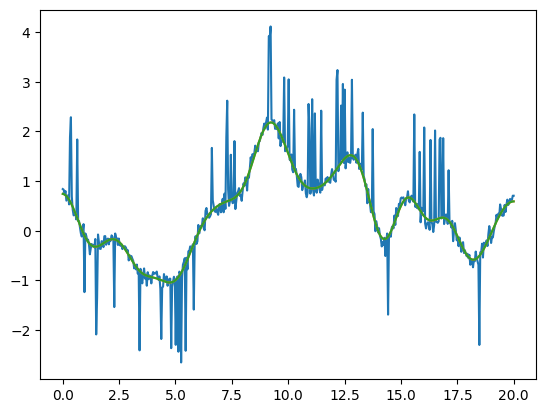

In [28]:
model.predict_in()
plt.plot(X,y)
plt.plot(X,model.mu_f)
plt.plot(X,model.predict_out(X)[0])

In [29]:
     
import time
import gpflow
import tensorflow as tf
import tensorflow_probability as tfp
tfpk = tfp.math.psd_kernels

class GVI_SGP_L(gpflow.models.BayesianModel):
    def __init__(self, X, y,inducing,kernel,structure="Tri", alpha=0.5,nu=2):
        super().__init__()
        self.X = X
        self.y = y

        self.alpha = gpflow.Parameter(alpha,trainable=False)
        self.inducing_variable = inducing
        self.N_u = inducing.shape[0]
        self.b=gpflow.Parameter(1.,transform=gpflow.utilities.positive())
        
        self.nu=tf.constant(nu,dtype=tf.float64)
        self.lambda_inv=tf.Variable([1.]*X.shape[0],trainable=False,dtype=tf.float64)
        # Variational parameters
        self.alpha = gpflow.Parameter(alpha, trainable=False, dtype=tf.float64)
        if structure == "Diag":
            self.Var_q = gpflow.Parameter([1.] * self.N_u, transform=gpflow.utilities.positive())
        else:
            self.Var_q = gpflow.Parameter(tf.linalg.eye(self.N_u), transform=gpflow.utilities.triangular())
        self.structure = structure
        self.kernel = kernel
        
        self.optimizer = tf.keras.optimizers.Adam(learning_rate=0.01)

    def stable_solve(self, mat, rhs):
        jitter = tf.eye(tf.shape(mat)[0], dtype=mat.dtype) * 1e-6
        L = tf.linalg.cholesky(mat + jitter)
        return tf.linalg.cholesky_solve(L, rhs)
    
    
    def maximum_log_likelihood_objective(self):
        pass
    
    def predict_in(self):
        K_uu = self.kernel(self.inducing_variable,self.inducing_variable)
        K_uf = self.kernel(self.inducing_variable, X)
        K_fu = tf.transpose(K_uf)

        Lambda_inv=tf.linalg.diag(self.lambda_inv)
        jitter = tf.eye(self.N_u, dtype=tf.float64) * 1e-6
        K_uu_inv = tf.linalg.inv(K_uu + jitter)

        if self.structure == "Diag":
            Sigma_u = tf.linalg.diag(self.Var_q)
        else:
            Sigma_u = self.Var_q @ tf.transpose(self.Var_q)
        Sigma_a = self.alpha * K_uu + (1.0 - self.alpha) * Sigma_u
        Sigma_a_inv = tf.linalg.inv(Sigma_a + jitter)

        precision_mid = self.alpha * Sigma_a_inv + (
                        K_uu_inv @ K_uf @ Lambda_inv @ K_fu @ K_uu_inv) *self.b**(-2)
        q1 = tf.linalg.inv(precision_mid + jitter)
        q2 = tf.matmul(K_uu_inv @ K_uf, Lambda_inv@ (self.y)*self.b**(-2))

        self.mu_u = tf.matmul(q1, q2)
        self.Sigma_u = Sigma_u
        
    def predict_out(self, Xnew):
        K_uu = self.kernel(self.inducing_variable, self.inducing_variable)
        K_xu = self.kernel(Xnew, self.inducing_variable)
        I_M = tf.eye(self.N_u, dtype=tf.float64)
        K_uu_inv = self.stable_solve(K_uu, I_M)

        f_var = self.kernel(Xnew, Xnew) - K_xu @ K_uu_inv @ tf.transpose(K_xu) + K_xu @ K_uu_inv @ self.Sigma_u @ K_uu_inv @ tf.transpose(K_xu)

        return K_xu @ K_uu_inv @ self.mu_u, tf.linalg.diag_part(f_var)
        
    
    @tf.function
    def train_step(self):
        with tf.GradientTape() as tape:
            K = self.kernel(self.X, self.X)
            K_uu = self.kernel(self.inducing_variable,self.inducing_variable)
            K_uf = self.kernel(self.inducing_variable, X)
            K_fu = tf.transpose(K_uf)

            K_uu_inv=tf.linalg.inv(K_uu+tf.linalg.eye(K_uu.shape[0],dtype=tf.float64)*gpflow.default_jitter())
            
            if self.structure == "Diag":
                Sigma_u = tf.linalg.diag(self.Var_q)
            else:
                Sigma_u = self.Var_q @ tf.transpose(self.Var_q)
            
            identity = tf.eye(self.N_u, dtype=K.dtype)
            jitter = identity * 1e-6

            Lambda_inv=tf.linalg.diag(self.lambda_inv)
            Sigma_a = self.alpha * K_uu + (1.0 - self.alpha) * Sigma_u
            Sigma_a_inv = tf.linalg.inv(Sigma_a + jitter)
            
            precision_mid = self.alpha * Sigma_a_inv + (
                        K_uu_inv @ K_uf @ Lambda_inv @ K_fu @ K_uu_inv)*self.b**(-2)
            q1 = tf.linalg.inv(precision_mid + jitter)
            q2 = tf.matmul(K_uu_inv @ K_uf, Lambda_inv @ self.y*self.b**(-2)) 
            mu_u = tf.matmul(q1, q2)

            # Log-determinants
            ld_Sig_a = tf.linalg.logdet(Sigma_a + jitter)
            ld_Sig_f = tf.linalg.logdet(Sigma_u + jitter)
            ld_K = tf.linalg.logdet(K_uu+jitter)

            # Loss terms
            term1 = 0.5 *  tf.transpose(mu_u) @ (K_uu_inv @ K_uf @ Lambda_inv @ K_fu @ K_uu_inv+Sigma_a_inv) @ mu_u*self.b**(-2)
            term2 = -  tf.transpose(mu_u)@K_uu_inv@K_uf@ Lambda_inv @ (self.y)*self.b**(-2)
            term4 = 0.5 * self.b**(-2) * tf.linalg.trace(K_uu_inv @ K_uf @ Lambda_inv @ K_fu @ K_uu_inv @ Sigma_u)
            term5 = -1.0 / (2.0 * (self.alpha - 1.0)) * (ld_Sig_a + (self.alpha - 1.0) * ld_Sig_f - self.alpha * ld_K)
            loss = tf.squeeze(term1 + term2 + term4 + term5)

        # Trainable parameters
        

        grads = tape.gradient(loss, self.trainable_variables)
        self.optimizer.apply_gradients(zip(grads,  self.trainable_variables))

        # Update Lambda using current mu_f
        residual = self.y - K_fu@K_uu_inv@mu_u 
        denom=tf.squeeze(residual)**2+tf.linalg.diag_part(K_fu@K_uu_inv@Sigma_u@K_uu_inv@K_uf)
        self.lambda_inv.assign(tf.squeeze((1 / denom)))
         
        return loss
    

    def train(self, max_steps=500, tolerance=0.5, patience=5):
        loss_history = []
        steps_without_improvement = 0
        start_time = time.time()

        for step in range(max_steps):
            loss_val = self.train_step()
            loss_val = loss_val.numpy()
            loss_history.append(loss_val)

            tf.print("Step:", step, "Loss:", loss_val)

            if step > 0:
                loss_diff = abs(loss_history[-1] - loss_history[-2])
                if loss_diff < tolerance:
                    steps_without_improvement += 1
                else:
                    steps_without_improvement = 0

                if steps_without_improvement >= patience:
                    print(f"Early stopping at step {step}: loss change < {tolerance} for {patience} steps.")
                    break
        end_time = time.time()
        elapsed = end_time - start_time
        print(f"Training completed in {elapsed:.3f} seconds.")      

N=X.shape[0]
Z = X[np.random.choice(N, 70, replace=False), :]
inducing_variable = gpflow.Parameter(Z,trainable=True)
kernel = gpflow.kernels.SquaredExponential(lengthscales=1.0, variance=1.0)
model = GVI_SGP_L(X, y,inducing_variable,kernel)
model.train()

Step: 0 Loss: 1823.752301800654
Step: 1 Loss: 239.8546523714752
Step: 2 Loss: 226.78136425875692
Step: 3 Loss: 214.44306047463937
Step: 4 Loss: 201.89206154011345
Step: 5 Loss: 189.05183619568902
Step: 6 Loss: 175.95196447524307
Step: 7 Loss: 162.5656279876668
Step: 8 Loss: 148.8245833740122
Step: 9 Loss: 134.65020969172116
Step: 10 Loss: 119.9737565105151
Step: 11 Loss: 104.71445483973116
Step: 12 Loss: 88.77292744514995
Step: 13 Loss: 72.04544047783219
Step: 14 Loss: 54.43290754379126
Step: 15 Loss: 35.831437561778046
Step: 16 Loss: 16.1250003717999
Step: 17 Loss: -4.8149770918354875
Step: 18 Loss: -27.12584827339043
Step: 19 Loss: -50.944409162670865
Step: 20 Loss: -76.41307490425476
Step: 21 Loss: -103.69945016811153
Step: 22 Loss: -133.0020656088446
Step: 23 Loss: -164.5237279777216
Step: 24 Loss: -198.44990863187593
Step: 25 Loss: -234.95631218599863
Step: 26 Loss: -274.2190295993735
Step: 27 Loss: -316.44307928227624
Step: 28 Loss: -361.9081971341617
Step: 29 Loss: -410.98250672

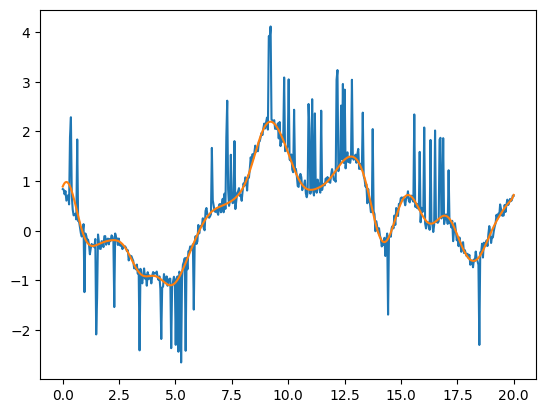

In [30]:
model.predict_in()
f,s=model.predict_out(X)
plt.plot(X,y)
plt.plot(X,model.predict_out(X)[0])

In [45]:
     
import time
import gpflow
import tensorflow as tf
import tensorflow_probability as tfp

class GVI_GP_AL(gpflow.models.BayesianModel):
    def __init__(self, X, y,kernel,inducing,quantile=0.5, alpha=0.5):
        super().__init__()
        self.X = X
        self.y = y
        self.k_11=tf.constant((1-2*quantile)/(alpha*(1-quantile)),dtype=tf.float64)
        self.k_22=tf.constant(2/(quantile*(1-quantile)),dtype=tf.float64)
        
        self.alpha = gpflow.Parameter(alpha,trainable=False)

        # GP parameters
        self.kernel = kernel
        self.inducing_variable = inducing
        self.b=gpflow.Parameter(1., transform=gpflow.utilities.positive())
        
        self.mu_alpha_inv=tf.Variable([1.]*X.shape[0],trainable=False,dtype=tf.float64)
        self.mu_alpha=tf.Variable([1.]*X.shape[0],trainable=False,dtype=tf.float64)
        self.optimizer = tf.keras.optimizers.Adam(learning_rate=0.01)
    
    def Egig_half(self,a,b_vec):
        expect_1 = (tf.math.sqrt(b_vec*a)+1)/a
        expect_2 = tf.math.sqrt(a/b_vec)
        return expect_1,expect_2

    def update_mu_alpha(self,mu_f,sigma_f_diag):
        diff_1= 2 * self.b**(-2) + self.k_11**2 / self.k_22 *  self.b**(-2)
        diff_2=(tf.squeeze(self.y-mu_f)**2+sigma_f_diag)/(self.k_22*self.b**2)
        self.mu_alpha,self.mu_alpha_inv=self.Egig_half(diff_1,diff_2)
    
    def stable_solve(self, mat, rhs):
        jitter = tf.eye(tf.shape(mat)[0], dtype=mat.dtype) * 1e-6
        L = tf.linalg.cholesky(mat + jitter)
        return tf.linalg.cholesky_solve(L, rhs)
    
    @tf.function
    def update_mu_f(self, Sigma_a_inv, sigma_2,Lambda_inv,bias):
        q1 = tf.linalg.inv(self.alpha * Sigma_a_inv + Lambda_inv / sigma_2)
        q2 = tf.matmul(Lambda_inv / sigma_2, (self.y-bias))
        return tf.matmul(q1, q2)
    
    def maximum_log_likelihood_objective(self):
        pass
    
    def predict_in(self):
        K = self.kernel(self.X, self.X)
        K_uu = self.kernel(self.inducing_variable,self.inducing_variable)
        K_uf = self.kernel(self.inducing_variable, X)
        K_fu = tf.transpose(K_uf)

        K_uu_inv=tf.linalg.inv(K_uu+tf.linalg.eye(K_uu.shape[0],dtype=tf.float64)*gpflow.default_jitter())

        Sigma_f = K_fu @ K_uu_inv @ K_uf
        
        N = tf.cast(tf.shape(K)[0],tf.float64)
        print(N.dtype)
        identity = tf.eye(N, dtype=K.dtype)
        jitter = identity * 1e-6
        K_j = K + jitter

        Lambda_inv=tf.linalg.diag(self.mu_alpha_inv)
        Sigma_a = self.alpha * K_j + (1.0 - self.alpha) * Sigma_f
        Sigma_a_inv = tf.linalg.inv(Sigma_a + jitter)
        bias_component=self.k_11*1/tf.reshape(self.mu_alpha_inv, (-1, 1))
        self.mu_f = self.update_mu_f(Sigma_a_inv, self.b**2,Lambda_inv,bias_component)
        self.Sigma_f=Sigma_f
        
    def predict_out(self,X):
        K_xold_xold = self.kernel(self.X, self.X)
        K_xold_xnew = self.kernel(X, self.X)
        jitter = 1e-6 * tf.eye(tf.shape(K_xold_xold)[0], dtype=K_xold_xold.dtype)
        K_inv = tf.linalg.inv(K_xold_xold + jitter)

        #compute variance
        f_var = self.kernel(X,X) - K_xold_xnew @ K_inv @ tf.transpose(K_xold_xnew)+ K_xold_xnew @ K_inv @ self.Sigma_f @ K_inv @ tf.transpose(K_xold_xnew)
        return K_xold_xnew @ K_inv @ self.mu_f, tf.linalg.diag_part(f_var)
    
    @tf.function
    def train_step(self):
        with tf.GradientTape() as tape:
            K = self.kernel(self.X, self.X)
            K_uu = self.kernel(self.inducing_variable,self.inducing_variable)
            K_uf = self.kernel(self.inducing_variable, X)
            K_fu = tf.transpose(K_uf)
            
            K_uu_inv=tf.linalg.inv(K_uu+tf.linalg.eye(K_uu.shape[0],dtype=tf.float64)*gpflow.default_jitter())
            
            
            Sigma_f = K_fu @ K_uu_inv @ K_uf
            
            N = tf.cast(tf.shape(K)[0],tf.float64)
            print(N.dtype)
            identity = tf.eye(N, dtype=K.dtype)
            jitter = identity * 1e-6
            K_j = K + jitter
            
            bias_component=self.k_11*1/tf.reshape(self.mu_alpha_inv, (-1, 1))
            Lambda_inv=tf.linalg.diag(self.mu_alpha_inv)
            Sigma_a = self.alpha * K_j + (1.0 - self.alpha) * Sigma_f
            Sigma_a_inv = tf.linalg.inv(Sigma_a + jitter)
            mu_f = self.update_mu_f(Sigma_a_inv, self.b**2,Lambda_inv,bias_component)
            
            # Log-determinants
            ld_Sig_a = tf.linalg.logdet(Sigma_a + jitter)
            ld_Sig_f = tf.linalg.logdet(Sigma_f + jitter)
            ld_K = tf.linalg.logdet(K_j)

            # Loss terms
            term1 = 0.5 * self.b**(-2) * tf.transpose(mu_f) @ (Lambda_inv+Sigma_a_inv) @ mu_f
            term2 = -self.b**(-2) * tf.transpose(mu_f) @Lambda_inv @ (self.y-bias_component)
            term3 = N* tf.math.log(self.b)
            term4 = 0.5 * self.b**(-2) * tf.linalg.trace(Lambda_inv @ Sigma_f)
            term5 = -1.0 / (2.0 * (self.alpha - 1.0)) * (ld_Sig_a + (self.alpha - 1.0) * ld_Sig_f - self.alpha * ld_K)
            loss = tf.squeeze(term1 + term2  + term3 + term4 + term5)

        # Trainable parameters
        

        grads = tape.gradient(loss, self.trainable_variables)
        self.optimizer.apply_gradients(zip(grads,  self.trainable_variables))
        """
        self.update_mu_alpha(mu_f,tf.linalg.diag_part(Sigma_f))
        """
        
        return loss


    def train(self, max_steps=500, tolerance=0.5, patience=5):
        loss_history = []
        steps_without_improvement = 0
        start_time = time.time()

        for step in range(max_steps):
            loss_val = self.train_step()
            loss_val = loss_val.numpy()
            loss_history.append(loss_val)

            tf.print("Step:", step, "Loss:", loss_val)

            if step > 0:
                loss_diff = abs(loss_history[-1] - loss_history[-2])
                if loss_diff < tolerance:
                    steps_without_improvement += 1
                else:
                    steps_without_improvement = 0

                if steps_without_improvement >= patience:
                    print(f"Early stopping at step {step}: loss change < {tolerance} for {patience} steps.")
                    break
        end_time = time.time()
        elapsed = end_time - start_time
        print(f"Training completed in {elapsed:.3f} seconds.")      

N=X.shape[0]
Z = X[np.random.choice(N, 70, replace=False), :]
inducing_variable = gpflow.Parameter(Z,trainable=True)
kernel = gpflow.kernels.SquaredExponential(lengthscales=1.0, variance=1.0)
model = GVI_GP_AL(X, y,kernel,inducing_variable)
model.train()

<dtype: 'float64'>
<dtype: 'float64'>
Step: 0 Loss: 193.11002460876557
Step: 1 Loss: 188.20497382350698
Step: 2 Loss: 183.26584761108347
Step: 3 Loss: 178.29137341308217
Step: 4 Loss: 173.28111344169764
Step: 5 Loss: 168.23287638649975
Step: 6 Loss: 163.1442685152362
Step: 7 Loss: 158.01177311625992
Step: 8 Loss: 152.83310940282468
Step: 9 Loss: 147.60581713599407
Step: 10 Loss: 142.32812144501946
Step: 11 Loss: 137.00026317140617
Step: 12 Loss: 131.62116768486328
Step: 13 Loss: 126.1898007766664
Step: 14 Loss: 120.70565203148783
Step: 15 Loss: 115.16497123103954
Step: 16 Loss: 109.56462912567042
Step: 17 Loss: 103.899527021452
Step: 18 Loss: 98.16498093029088
Step: 19 Loss: 92.35438987970383
Step: 20 Loss: 86.46248428050495
Step: 21 Loss: 80.48317422986861
Step: 22 Loss: 74.41181353670203
Step: 23 Loss: 68.24562370592645
Step: 24 Loss: 61.98478817142774
Step: 25 Loss: 55.63118858725966
Step: 26 Loss: 49.187972403216975
Step: 27 Loss: 42.65745632018229
Step: 28 Loss: 36.04044574147076


<dtype: 'float64'>


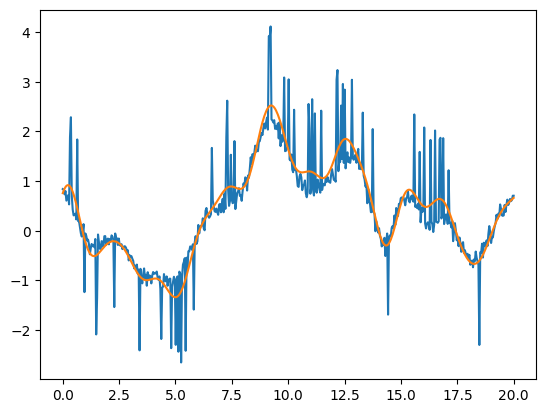

In [46]:
plt.plot(X,y)
model.predict_in()
plt.plot(X,model.mu_f)

In [47]:
ind=tf.squeeze(y-model.mu_f)>0
sum(ind.numpy())/len(ind.numpy())

0.44

In [48]:
model

name,class,transform,prior,trainable,shape,dtype,value
GVI_GP_AL.alpha,Parameter,Identity,,False,(),float64,0.5
GVI_GP_AL.kernel.variance,Parameter,Softplus,,True,(),float64,0.20991918908769672
GVI_GP_AL.kernel.lengthscales,Parameter,Softplus,,True,(),float64,0.7951827018148396
GVI_GP_AL.inducing_variable,Parameter,Identity,,True,"(70, 1)",float64,[[1.61272...
GVI_GP_AL.b,Parameter,Softplus,,True,(),float64,0.08225139221376783
GVI_GP_AL.mu_alpha_inv,ResourceVariable,,,False,"(500,)",float64,"[1., 1., 1...."
GVI_GP_AL.mu_alpha,ResourceVariable,,,False,"(500,)",float64,"[1., 1., 1...."


In [14]:
import tensorflow as tf
tf.keras.backend.set_floatx('float64')
import numpy as np
import gpflow
from matplotlib import pyplot as plt


def generate_sample(
    n_points: int = 500,
    sigma_n: float = 0.5,
    heteroskedastic: bool = False,
    percent_output_outliers: float = 0.0,
    add_input_outliers: bool = False,
    n_input_outliers: int = 10,
    input_outlier_spread: float = 20.0,
    seed: int = 10,
    plot: bool = True
) -> tuple[np.ndarray, np.ndarray, np.ndarray, gpflow.kernels.Kernel]:
    np.random.seed(seed)
    tf.random.set_seed(seed)

    # Kernel
    kernel = gpflow.kernels.SquaredExponential(lengthscales=1.0, variance=1.0)

    # Original input and function
    x = np.linspace(0, 20, n_points).reshape(-1, 1)
    f = np.random.multivariate_normal(
        mean=np.zeros(n_points),
        cov=kernel(x, x) + 1e-8 * np.eye(n_points)
    ).reshape(-1, 1)

    # Noise: homoskedastic or heteroskedastic
    if heteroskedastic:
        # Example: noise increases linearly with x
        noise_scale = sigma_n * (1 + 0.1 * x.squeeze())
    else:
        noise_scale = sigma_n * np.ones(n_points)

    # ✅ Correct call: draw elementwise noise
    y_obs = f.squeeze() + np.random.normal(loc=0.0, scale=noise_scale)
    y_obs = y_obs.reshape(-1, 1)

    # Apply output outliers
    if percent_output_outliers > 0:
        i_mis = np.random.choice(n_points, int(percent_output_outliers * n_points), replace=False)
        factor = 5.0  # max absolute change
        y_obs[i_mis] += np.random.uniform(-factor, factor, size=(i_mis.size, 1))

    # Apply input outliers
    x_obs = x.copy()
    if add_input_outliers and n_input_outliers > 0:
        replace_idx = np.random.choice(n_points, n_input_outliers, replace=False)
        x_min, x_max = x.min(), x.max()

        x_outliers_low = np.random.uniform(
            low=x_min - input_outlier_spread,
            high=x_min - 0.1 * input_outlier_spread,
            size=(n_input_outliers // 2, 1)
        )
        x_outliers_high = np.random.uniform(
            low=x_max + 0.1 * input_outlier_spread,
            high=x_max + input_outlier_spread,
            size=(n_input_outliers - x_outliers_low.shape[0], 1)
        )
        x_outliers = np.vstack([x_outliers_low, x_outliers_high])
        x_obs[replace_idx] = x_outliers

    # Optional plotting
    if plot:
        plt.figure(figsize=(10, 5))
        plt.plot(x, f, 'k--', lw=2, label='true f(x)')
        plt.plot(x_obs, y_obs, 'r.', ms=8, alpha=0.7, label='observed data')
        plt.legend()
        x_min_plot = x.min() - (input_outlier_spread if add_input_outliers else 0)
        x_max_plot = x.max() + (input_outlier_spread if add_input_outliers else 0)
        plt.xlim(x_min_plot, x_max_plot)
        title = "Generated GP Sample"
        if heteroskedastic:
            title += " (Heteroskedastic Noise)"
        else:
            title += " (Homoskedastic Noise)"
        plt.title(title)
        plt.show()

    return x_obs, y_obs, f, kernel


In [35]:
from notebooks.random_stuff.model_altamirano import RCGPR, RCSGPR

standard_gp = gpflow.models.GPR(
    (X, y),
kernel=gpflow.kernels.SquaredExponential(lengthscales=0.01,variance = 0.01),
noise_variance = 0.01
)

opt = gpflow.optimizers.Scipy()
opt_options = dict()
res = opt.minimize(standard_gp.training_loss_closure(), standard_gp.trainable_variables, options=opt_options)
f_mean, f_var = standard_gp.predict_f(X, full_cov=False)


In [36]:
model = RCSGPR(
        (x_obs, y_obs),
        kernel=gpflow.kernels.SquaredExponential(lengthscales=0.01,variance = 0.01),
        weighting_function=w.IMQ(C=np.quantile(np.abs(y_obs), 0.95)),
        noise_variance=sigma_n**2 ,
        inducing_variable = inducing_variable
)
gpflow.set_trainable(model.likelihood.variance, False)

opt = gpflow.optimizers.Scipy()
log = opt.minimize(model.training_loss_closure(), model.trainable_variables)
f_mean, _ = model.predict_f(x, full_cov=False)

In [37]:
import numpy as np
import pandas as pd
import tensorflow as tf
import gpflow
import w  # assuming your weighting function is in module w

cases = [
    [0.0, False, False],   # clean, homoskedastic
    [0.1, False, False],   # output outliers only
    [0.1, True,  False],   # both types of outliers
]
seeds = [1, 2, 3, 4, 5]
N = 400

results = []  # will store dicts {case, seed, model, value}

# helper
def save_result(case, seed, model_name, value):
    if value is None:
        return
    val = float(value)
    # exclude >1 right away if you prefer (or keep and filter later)
    if val <= 1:
        results.append({
            "case": case,
            "seed": seed,
            "model": model_name,
            "value": val
        })

# --- Main loops ---
for ci, (perc, input_o, hetero) in enumerate(cases):
    for seed in seeds:
        # generate data
        X, y, f, kernel_from_data = generate_sample(
            seed=seed, plot=False,
            add_input_outliers=input_o,
            percent_output_outliers=perc,
            heteroskedastic=hetero,
            n_points=N
        )

        Z = np.linspace(np.min(X), np.max(X), 50)[:, None]
        inducing_variable = gpflow.Parameter(Z, trainable=False)

        try:
            kernel = gpflow.kernels.SquaredExponential()
            model = GVI_RCGP_alpha(X, y, kernel)
            model.internal_opt()
            model.predict_ins()
            mu_f, _ = model.predict_out(X)
            save_result(ci, seed, "GVI_RCGP_alpha", tf.reduce_mean((f - mu_f) ** 2))
        except Exception as e:
            print(f"GVI_RCGP_alpha failed: {e}")

        try:
            kernel = gpflow.kernels.SquaredExponential()
            model = GVI_RCGP_alpha(X, y, kernel, objective="predictive", lambda_method="predictive")
            model.internal_opt()
            model.predict_ins()
            mu_f, _ = model.predict_out(X)
            save_result(ci, seed, "GVI_RCGP_alpha_predictive", tf.reduce_mean((f - mu_f) ** 2))
        except Exception as e:
            print(f"GVI_RCGP_alpha (predictive) failed: {e}")

        try:
            model = GVI_SRCGPR_alpha(X, y, inducing_variable)
            model.internal_opt()
            model.predict_ins()
            mu_f, _ = model.predict_out(X)
            save_result(ci, seed, "GVI_SRCGPR_alpha", tf.reduce_mean((f - mu_f) ** 2))
        except Exception as e:
            print(f"GVI_SRCGPR_alpha failed: {e}")

        try:
            kernel = gpflow.kernels.SquaredExponential()
            model = GVI_GP_T(X, y, inducing_variable)
            model.train()
            model.predict_in()
            mu_f, _ = model.predict_out(X)
            save_result(ci, seed, "GVI_GP_T", tf.reduce_mean((f - mu_f) ** 2))
        except Exception as e:
            print(f"GVI_GP_T failed: {e}")

        try:
            model = GVI_SGP_T(X, y, inducing_variable, kernel)
            model.train()
            model.predict_in()
            mu_f, _ = model.predict_out(X)
            save_result(ci, seed, "GVI_SGP_T", tf.reduce_mean((f - mu_f) ** 2))
        except Exception as e:
            print(f"GVI_SGP_T failed: {e}")

        try:
            model = GVI_GP_L(X, y, kernel, inducing_variable)
            model.train()
            model.predict_in()
            mu_f, _ = model.predict_out(X)
            save_result(ci, seed, "GVI_GP_L", tf.reduce_mean((f - mu_f) ** 2))
        except Exception as e:
            print(f"GVI_GP_L failed: {e}")

        try:
            model = GVI_SGP_L(X, y, inducing_variable, kernel)
            model.train()
            model.predict_in()
            mu_f, _ = model.predict_out(X)
            save_result(ci, seed, "GVI_SGP_L", tf.reduce_mean((f - mu_f) ** 2))
        except Exception as e:
            print(f"GVI_SGP_L failed: {e}")

        try:
            N = X.shape[0]
            Z = X[np.random.choice(N, 50, replace=False), :]
            inducing_variable = gpflow.Parameter(Z, trainable=True)
            model = GVI_GP_WELSCH(X, y, inducing_variable)
            model.train(max_steps=200)
            save_result(ci, seed, "GVI_GP_WELSCH", tf.reduce_mean((f - model.mu_f) ** 2))
        except Exception as e:
            print(f"GVI_GP_WELSCH failed: {e}")

        try:
            standard_gp = RCGPR(
                (X, y),
                kernel=gpflow.kernels.SquaredExponential(lengthscales=0.01, variance=0.01),
                noise_variance=0.01
            )
            opt = gpflow.optimizers.Scipy()
            res = opt.minimize(standard_gp.training_loss_closure(), standard_gp.trainable_variables)
            f_mean, f_var = standard_gp.predict_f(X, full_cov=False)
            save_result(ci, seed, "Standard_GPR", tf.reduce_mean((f - f_mean) ** 2))
        except Exception as e:
            print(f"Standard GPR failed: {e}")

        try:
            model = RCSGPR(
                (x_obs, y_obs),
                kernel=gpflow.kernels.SquaredExponential(lengthscales=0.01, variance=0.01),
                weighting_function=w.IMQ(C=np.quantile(np.abs(y_obs), 0.95)),
                noise_variance=sigma_n ** 2,
                inducing_variable=inducing_variable
            )
            gpflow.set_trainable(model.likelihood.variance, False)
            opt = gpflow.optimizers.Scipy()
            log = opt.minimize(model.training_loss_closure(), model.trainable_variables)
            f_mean, _ = model.predict_f(X, full_cov=False)
            save_result(ci, seed, "RCSGPR", tf.reduce_mean((f - f_mean) ** 2))
        except Exception as e:
            print(f"RCSGPR failed: {e}")

# --- Convert to DataFrame for analysis ---
df = pd.DataFrame(results)

# --- Compute averages over seeds ---
summary = df.groupby(["case", "model"]).agg(
    mean=("value", "mean"),
    std=("value", "std"),
    n=("value", "count")
).reset_index()

print(summary)


Cause: for/else statement not yet supported
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Cause: for/else statement not yet supported
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
<dtype: 'float64'>
<dtype: 'float64'>
Step: 0 Loss: 39.942782895043365
Step: 1 Loss: 47.97997805381743
Step: 2 Loss: 45.685886347219366
Step: 3 Loss: 43.03055263657939
Step: 4 Loss: 40.339454387805006
Step: 5 Loss: 37.65413226413244
Step: 6 Loss: 34.98035357161774
Step: 7 Loss: 32.31930384346714
Step: 8 Loss: 29.671686140702093
Step: 9 Loss: 27.038098564503628
Step: 10 Loss: 24.41912612506121
Step: 11 Loss: 21.81542913994798
Step: 12 Loss: 19.227561936901566
Step: 13 Loss: 16.65613808702045
Step: 14 Loss: 14.101778981382893
Step: 15 Loss: 11.56503676418265
Step: 16 Loss: 9.046520854577807
Step: 17 Loss: 6.5467914349416105
Step: 18 Loss: 4.066461648859615
Step: 19 Loss: 1.6059856217739252
Step: 20 Loss: -0.834021283

2025-09-10 18:18:19.456527: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: INVALID_ARGUMENT: Input is not invertible.


<dtype: 'float64'>
<dtype: 'float64'>
Step: 0 Loss: 95.16024060168718
Step: 1 Loss: 123.51976823340891
Step: 2 Loss: 122.37350816108352
Step: 3 Loss: 119.41950553788269
Step: 4 Loss: 116.23938614734328
Step: 5 Loss: 113.04877094187873
Step: 6 Loss: 109.87767898051987
Step: 7 Loss: 106.73120158867027
Step: 8 Loss: 103.61085598068667
Step: 9 Loss: 100.51759727239909
Step: 10 Loss: 97.45227229686537
Step: 11 Loss: 94.41569083193053
Step: 12 Loss: 91.40863548019291
Step: 13 Loss: 88.43186147377332
Step: 14 Loss: 85.48609496732496
Step: 15 Loss: 82.57203127968802
Step: 16 Loss: 79.69033344715416
Step: 17 Loss: 76.84163082116385
Step: 18 Loss: 74.02651804788911
Step: 19 Loss: 71.24555403312888
Step: 20 Loss: 68.49926113427148
Step: 21 Loss: 65.78812450236268
Step: 22 Loss: 63.112591628066355
Step: 23 Loss: 60.47307196556437
Step: 24 Loss: 57.86993691808823
Step: 25 Loss: 55.30351977685473
Step: 26 Loss: 52.774116026228
Step: 27 Loss: 50.281983679342034
Step: 28 Loss: 47.827343740982144
Step:

2025-09-10 18:19:05.538197: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: INVALID_ARGUMENT: Input is not invertible.


<dtype: 'float64'>
<dtype: 'float64'>
Step: 0 Loss: 166.0684147546269
Step: 1 Loss: 178.34486478241269
Step: 2 Loss: 176.63882552258698
Step: 3 Loss: 174.07289307773954
Step: 4 Loss: 171.38427907600277
Step: 5 Loss: 168.705376529389
Step: 6 Loss: 166.05281678482467
Step: 7 Loss: 163.42912950076968
Step: 8 Loss: 160.8350966961859
Step: 9 Loss: 158.27125782091494
Step: 10 Loss: 155.73808115914088
Step: 11 Loss: 153.2359813902123
Step: 12 Loss: 150.76532272550705
Step: 13 Loss: 148.3264211433539
Step: 14 Loss: 145.91954652649378
Step: 15 Loss: 143.54492466709752
Step: 16 Loss: 141.20273892115938
Step: 17 Loss: 138.89313190409726
Step: 18 Loss: 136.61620695668373
Step: 19 Loss: 134.37202956050646
Step: 20 Loss: 132.1606287702124
Step: 21 Loss: 129.98199833189898
Step: 22 Loss: 127.83609791848392
Step: 23 Loss: 125.72285417314421
Step: 24 Loss: 123.64216165763918
Step: 25 Loss: 121.59388397498606
Step: 26 Loss: 119.57785466310523
Step: 27 Loss: 117.59387831643781
Step: 28 Loss: 115.64173153

...

<dtype: 'float64'>
<dtype: 'float64'>
Step: 0 Loss: 266.11537540993857
Step: 1 Loss: 269.1296724042252
Step: 2 Loss: 268.6192204490194
Step: 3 Loss: 266.18932384576647
Step: 4 Loss: 263.4493815530508
Step: 5 Loss: 260.66398269286844
Step: 6 Loss: 257.88238161249893
Step: 7 Loss: 255.1156038504643
Step: 8 Loss: 252.3669179714494
Step: 9 Loss: 249.6377010356375
Step: 10 Loss: 246.9287886158159
Step: 11 Loss: 244.24083971280032
Step: 12 Loss: 241.57444497378953
Step: 13 Loss: 238.93015992026153
Step: 14 Loss: 236.3085147124307
Step: 15 Loss: 233.71001681685863
Step: 16 Loss: 231.1351513765443
Step: 17 Loss: 228.58438100621072
Step: 18 Loss: 226.05814552711405
Step: 19 Loss: 223.55686178252773
Step: 20 Loss: 221.08092343898602
Step: 21 Loss: 218.6307009401888
Step: 22 Loss: 216.2065413998695
Step: 23 Loss: 213.8087686282022
Step: 24 Loss: 211.43768301296413
Step: 25 Loss: 209.0935614666201
Step: 26 Loss: 206.77665743574937
Step: 27 Loss: 204.48720075320452
Step: 28 Loss: 202.22539772533577

2025-09-10 18:20:47.302652: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: INVALID_ARGUMENT: Input is not invertible.


<dtype: 'float64'>
<dtype: 'float64'>
Step: 0 Loss: 186.68681341590337
Step: 1 Loss: 184.61885264524287
Step: 2 Loss: 182.13156589646505
Step: 3 Loss: 179.01841498933342
Step: 4 Loss: 175.94250753287315
Step: 5 Loss: 172.8981702692727
Step: 6 Loss: 169.87880511377853
Step: 7 Loss: 166.88367379008957
Step: 8 Loss: 163.91326447058958
Step: 9 Loss: 160.96824197344128
Step: 10 Loss: 158.04927267090042
Step: 11 Loss: 155.15699876746618
Step: 12 Loss: 152.2920339284648
Step: 13 Loss: 149.45496146032224
Step: 14 Loss: 146.64633290609927
Step: 15 Loss: 143.86666651654696
Step: 16 Loss: 141.11644625135875
Step: 17 Loss: 138.3961206577962
Step: 18 Loss: 135.70610217022914
Step: 19 Loss: 133.0467663703926
Step: 20 Loss: 130.41845159895456
Step: 21 Loss: 127.82145862730079
Step: 22 Loss: 125.25605052345696
Step: 23 Loss: 122.72245274151288
Step: 24 Loss: 120.22085333120566
Step: 25 Loss: 117.75140342294966
Step: 26 Loss: 115.3142179218263
Step: 27 Loss: 112.90937632068017
Step: 28 Loss: 110.536923

2025-09-10 18:21:31.825224: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: INVALID_ARGUMENT: Input is not invertible.


    case                      model      mean       std  n
0      0                   GVI_GP_L  0.012448  0.003261  5
1      0                   GVI_GP_T  0.014278  0.005500  5
2      0              GVI_GP_WELSCH  0.184315  0.121935  4
3      0             GVI_RCGP_alpha  0.061017  0.031974  5
4      0  GVI_RCGP_alpha_predictive  0.041195  0.030968  5
5      0                  GVI_SGP_L  0.043272  0.023213  5
6      0                  GVI_SGP_T  0.016367  0.003427  5
7      0           GVI_SRCGPR_alpha  0.012184  0.001410  5
8      1                   GVI_GP_L  0.016437  0.004682  5
9      1                   GVI_GP_T  0.020122  0.008187  5
10     1              GVI_GP_WELSCH  0.327964  0.098944  3
11     1             GVI_RCGP_alpha  0.112504  0.061227  5
12     1  GVI_RCGP_alpha_predictive  0.075409  0.049510  5
13     1                  GVI_SGP_L  0.058747  0.021588  5
14     1                  GVI_SGP_T  0.030425  0.015118  5
15     1           GVI_SRCGPR_alpha  0.045446  0.019524 

In [40]:
results

[{'case': 0,
  'seed': 1,
  'model': 'GVI_RCGP_alpha',
  'value': 0.04612642394798417},
 {'case': 0,
  'seed': 1,
  'model': 'GVI_RCGP_alpha_predictive',
  'value': 0.022913288938077866},
 {'case': 0,
  'seed': 1,
  'model': 'GVI_SRCGPR_alpha',
  'value': 0.011289935345100229},
 {'case': 0, 'seed': 1, 'model': 'GVI_GP_T', 'value': 0.012524954365063387},
 {'case': 0, 'seed': 1, 'model': 'GVI_SGP_T', 'value': 0.015387365381969489},
 {'case': 0, 'seed': 1, 'model': 'GVI_GP_L', 'value': 0.010344332642981813},
 {'case': 0, 'seed': 1, 'model': 'GVI_SGP_L', 'value': 0.03341132869145251},
 {'case': 0,
  'seed': 1,
  'model': 'GVI_GP_WELSCH',
  'value': 0.26453055941915665},
 {'case': 0,
  'seed': 2,
  'model': 'GVI_RCGP_alpha',
  'value': 0.11502429634117554},
 {'case': 0,
  'seed': 2,
  'model': 'GVI_RCGP_alpha_predictive',
  'value': 0.09540414002936198},
 {'case': 0,
  'seed': 2,
  'model': 'GVI_SRCGPR_alpha',
  'value': 0.012164387034859453},
 {'case': 0, 'seed': 2, 'model': 'GVI_GP_T', 'v

In [18]:
import numpy as np
import pandas as pd
import tensorflow as tf
import gpflow
import w  # assuming your weighting function is in module w

cases = [
    [0.0, False, False],   # clean, homoskedastic
    [0.1, False, False],   # output outliers only
    [0.1, True, False],   # output outliers only
]
seeds = [1]
N = 400

results = []  # will store dicts {case, seed, model, value}

# helper
def save_result(case, seed, model_name, value):
    if value is None:
        return
    val = float(value)
    # exclude >1 right away if you prefer (or keep and filter later)
    if val <= 1:
        results.append({
            "case": case,
            "seed": seed,
            "model": model_name,
            "value": val
        })

# --- Main loops ---
for ci, (perc, input_o, hetero) in enumerate(cases):
    for seed in seeds:
        # generate data
        X, y, f, kernel_from_data = generate_sample(
            seed=seed, plot=False,
            add_input_outliers=input_o,
            percent_output_outliers=perc,
            heteroskedastic=hetero,
            n_points=N
        )

        Z = np.linspace(np.min(X), np.max(X), 50)[:, None]
        inducing_variable = gpflow.Parameter(Z, trainable=False)



        try:
            N = X.shape[0]
            Z = X[np.random.choice(N, 50, replace=False), :]
            inducing_variable = gpflow.Parameter(Z, trainable=True)
            kernel = gpflow.kernels.SquaredExponential()
            model = GVI_SGP_WELSCH(X, y, inducing_variable,kernel)
            model.train(max_steps=2500)
            mu,s=model.predict_out(X)
            save_result(ci, seed, "GVI_GSP_WELSCH", tf.reduce_mean((f - mu) ** 2))
        except Exception as e:
            print(f"GVI_GP_WELSCH failed: {e}")



Step: 0 Loss: 93449.92986336074
Step: 1 Loss: 90851.17244132701
Step: 2 Loss: 89341.73860778639
Step: 3 Loss: 87973.32146489773
Step: 4 Loss: 86684.20887532695
Step: 5 Loss: 85528.77113738701
Step: 6 Loss: 84524.89622657838
Step: 7 Loss: 83658.91930089021
Step: 8 Loss: 82864.91770613416
Step: 9 Loss: 82083.86538983072
Step: 10 Loss: 81309.19523778536
Step: 11 Loss: 80559.19995169259
Step: 12 Loss: 79847.23403243786
Step: 13 Loss: 79170.01416760944
Step: 14 Loss: 78513.04496931433
Step: 15 Loss: 77861.03989537618
Step: 16 Loss: 77204.33499231031
Step: 17 Loss: 76542.30272358956
Step: 18 Loss: 75881.52248690581
Step: 19 Loss: 75229.16731350534
Step: 20 Loss: 74585.60651432442
Step: 21 Loss: 73939.01816891988
Step: 22 Loss: 73269.25692865661
Step: 23 Loss: 72556.92049811427
Step: 24 Loss: 71787.23704962152
Step: 25 Loss: 70946.74183481644
Step: 26 Loss: 70022.73418327751
Step: 27 Loss: 69013.55237293329
Step: 28 Loss: 67952.99238020706
Step: 29 Loss: 66901.9566933946
Step: 30 Loss: 65837.

In [19]:
results

[{'case': 0,
  'seed': 1,
  'model': 'GVI_GSP_WELSCH',
  'value': 0.01654313529012347},
 {'case': 1,
  'seed': 1,
  'model': 'GVI_GSP_WELSCH',
  'value': 0.031697500378075345},
 {'case': 2,
  'seed': 1,
  'model': 'GVI_GSP_WELSCH',
  'value': 0.07186356705985096}]

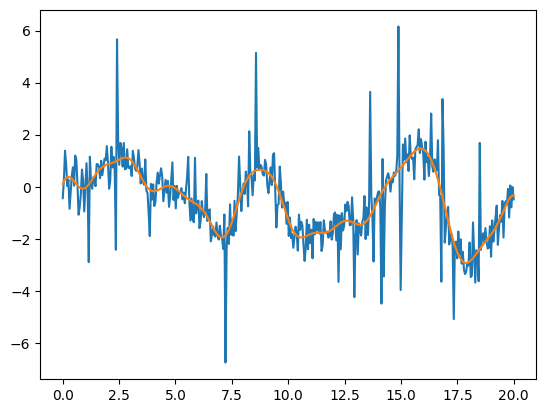

In [47]:
plt.plot(X,y)
plt.plot(X,mu)

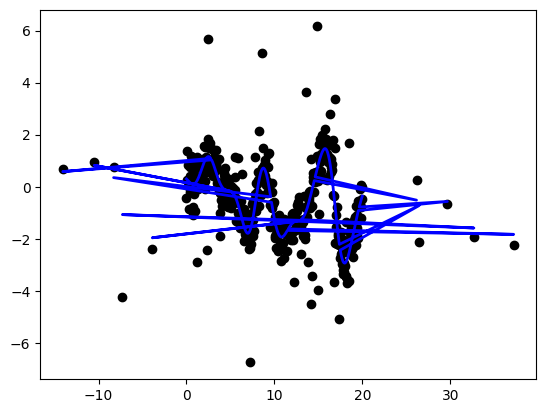

In [27]:
import gpflow
import numpy as np

# Kernel
kernel = gpflow.kernels.SquaredExponential()

# Likelihood: Student-t
likelihood = gpflow.likelihoods.StudentT(scale=0.5, df=3.0)

# Variational GP
model = gpflow.models.VGP((X, y), kernel=kernel, likelihood=likelihood)

# Train
opt = gpflow.optimizers.Scipy()
opt.minimize(model.training_loss, model.trainable_variables)

mean, var = model.predict_f(X)

import matplotlib.pyplot as plt
plt.scatter(X, y, c='k')
plt.plot(X, mean, 'b', lw=2)
plt.show()


In [28]:
l=mean

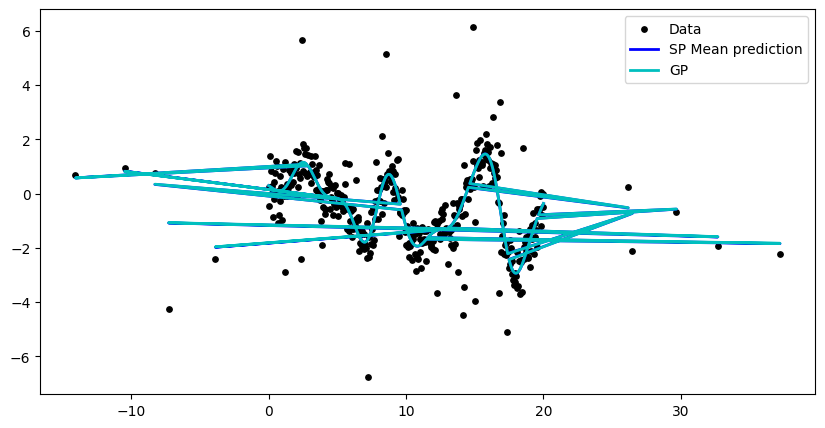

In [30]:
# Kernel
kernel = gpflow.kernels.SquaredExponential()

# Likelihood: Student-t
likelihood = gpflow.likelihoods.StudentT(scale=0.5, df=3.0)

# Inducing points: pick 50 evenly spaced in the input domain
Z = np.linspace(np.min(X), np.max(X), 50)[:, None]

# Variational Sparse GP (SVGP)
model = gpflow.models.SVGP(kernel=kernel,
                           likelihood=likelihood,
                           inducing_variable=Z)

# Training with minibatch stochastic optimization
data = (X, y)
training_loss = model.training_loss_closure(data)

opt = gpflow.optimizers.Scipy()
opt.minimize(training_loss, model.trainable_variables)

# Predictions
mean, var = model.predict_f(X)

# Plot
plt.figure(figsize=(10, 5))
plt.scatter(X, y, c='k', s=15, label="Data")
plt.plot(X, mean, 'b', lw=2, label="SP Mean prediction")
plt.plot(X, l, 'c', lw=2, label="GP")
plt.legend()
plt.show()

In [31]:
tf.reduce_mean((mean-l)**2)

<tf.Tensor: shape=(), dtype=float64, numpy=2.5493372202015216e-05>

In [51]:
import numpy as np
import pandas as pd
import tensorflow as tf
import gpflow
from sklearn.model_selection import train_test_split
import w  # weighting function module

# ==== Dataset loaders ====
def load_concrete_dataset():
    url = "https://archive.ics.uci.edu/ml/machine-learning-databases/concrete/compressive/Concrete_Data.xls"
    df = pd.read_excel(url)
    X = df.iloc[:, :-1].values
    y = df.iloc[:, -1].values
    return X, y

def load_energy_dataset():
    url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00242/ENB2012_data.xlsx"
    df = pd.read_excel(url)
    X = df.iloc[:, :8].values
    y = df.iloc[:, 8].values
    return X, y

def load_yacht_dataset():
    url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00243/yacht_hydrodynamics.data"
    df = pd.read_csv(url, delim_whitespace=True, header=None)
    X = df.iloc[:, :-1].values
    y = df.iloc[:, -1].values
    return X, y

def load_boston_dataset():
    data_url = "https://archive.ics.uci.edu/ml/machine-learning-databases/housing/housing.data"
    columns = [
        "CRIM", "ZN", "INDUS", "CHAS", "NOX", "RM", "AGE",
        "DIS", "RAD", "TAX", "PTRATIO", "B", "LSTAT", "MEDV"
    ]
    df = pd.read_csv(data_url, sep=r"\s+", header=None, names=columns)
    X = df.drop("MEDV", axis=1).values
    y = df["MEDV"].values
    return X, y

# ==== Inject output outliers ====

def add_output_outliers(y, perc, seed):
    rng = np.random.default_rng(seed)
    y_noisy = y.copy()
    n_out = int(len(y) * perc)
    if n_out > 0:
        idx = rng.choice(len(y), n_out, replace=False)
        sigma = np.std(y)
        # Uniform noise between 3σ and 5σ
        noise = rng.uniform(low=3*sigma, high=5*sigma, size=(n_out, 1))
        # Randomly flip half of them negative to mimic "uniform" contamination
        signs = rng.choice([-1, 1], size=(n_out, 1))
        noise *= signs
        y_noisy[idx, 0] += noise[:, 0]
    return y_noisy

# ==== Store results ====
results = []
def save_result(dataset, seed, model_name, value):
    results.append({
        "dataset": dataset,
        "seed": seed,
        "model": model_name,
        "value": float(value)
    })

# ==== Experiments ====
datasets = {
    "Concrete": load_concrete_dataset}
""",
    "Energy": load_energy_dataset,
    "Yacht": load_yacht_dataset,
    "Boston": load_boston_dataset
}"""
seeds = [1]
perc = 0.1  # 10% outliers
test_ratio = 0.2  # 4:1 split

for dname, loader in datasets.items():
    X, y = loader()
    
    gpflow.config.set_default_float(np.float64)
    
    X = np.asarray(X)
    if X.ndim == 1:
        X = X.reshape(-1, 1)
    
    y = np.asarray(y).reshape(-1, 1).astype(np.float64)

    for seed in seeds:
        # train-test split
        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=test_ratio, random_state=seed
        )

        # add output outliers only in the training set
        y_train_out = add_output_outliers(y_train, perc, seed)

        # inducing points (50 points from training)
        if X_train.shape[1] == 1:
            Z = np.linspace(np.min(X_train), np.max(X_train), 50)[:, None]
        else:
            rng = np.random.default_rng(seed)
            idx = rng.choice(X_train.shape[0], 50, replace=False)
            Z = X_train[idx]

        inducing_variable = gpflow.Parameter(Z, trainable=False)

        # === Run models ===


# === Aggregate results ===
df = pd.DataFrame(results)
summary = df.groupby(["dataset", "model"]).agg(
    mean=("value", "mean"),
    std=("value", "std"),
    n=("value", "count")
).reset_index()

print(summary)


Concrete - GVI_RCGP_alpha failed: in user code:

    File "/var/folders/3j/3sftgpw558d6tvmshw2b29jc0000gn/T/ipykernel_1142/2988217775.py", line 76, in train_step  *
        loss = self.GVI_step()
    File "/var/folders/3j/3sftgpw558d6tvmshw2b29jc0000gn/T/ipykernel_1142/2988217775.py", line 150, in GVI_step  *
        self.sigma.assign(tf.squeeze(tf.sqrt(tf.transpose(y-mu_f-m_y)@J_w_inv@(y-mu_f-m_y)/tf.reduce_sum(J_w_inv))))

    ValueError: Dimensions must be equal, but are 1030 and 824 for '{{node sub_7}} = Sub[T=DT_DOUBLE](sub_7/x, MatMul_1)' with input shapes: [1030,1], [824,1].



KeyboardInterrupt: 

In [50]:
results

[]